
# FFT-75 4096-byte Scenario 1 — ByteFusion Duo

This notebook replaces the XGBoost representation with two complementary neural models trained **simultaneously but independently**, one per T4 GPU:

1. **ByteSeqNet** — a ByteRCNN-inspired raw-byte sequence model using trainable byte embeddings, multi-kernel 1D residual convolutions, an efficiently downsampled bidirectional GRU, and attention pooling.
2. **BitVisionNet** — a Byte2Image-inspired visual model using eight cross-byte bit-shift views, eight bit-plane views, a ConvNeXt-style 2D backbone, and a raw-byte summary branch.

The models do not exchange gradients. A single bounded-memory NPZ stream feeds both GPUs, avoiding duplicate decompression and avoiding a 25 GB raw-data cache. Both models use mixed precision, EMA weights, label smoothing, latent mixup, semantic-family auxiliary supervision, recovery checkpoints, and a hard 12 GB VRAM ceiling per GPU.

After training, the notebook:

- Predicts the complete official validation and test splits.
- Fits scalar and classwise regularized logit blenders using disjoint validation fitting/selection halves.
- Freezes the selected calibrator before the official test calculation.
- Produces the same detailed metrics, confidence intervals, per-class reports, family analysis, confusion analysis, calibration plots, resource plots, benchmark plots, and portable artifact archive used in the previous pipeline.

## Research basis

- **ByteRCNN** reported 83.9% on FFT-75, 4096-byte Scenario 1 and combines recurrent and multi-kernel convolutional processing. Official implementation: `kristian-fer/ByteRCNN`; DOI: `10.1109/ACCESS.2023.3340441`.
- **Byte2Image / ByteNet** showed that exposing intrabyte bit structure and treating fragments visually improves file-fragment classification. Official implementation: `wenyang001/Byte2Image`; DOI: `10.1109/TMM.2024.3521830`.
- **Mixup** regularizes intermediate representations: Zhang et al., *mixup: Beyond Empirical Risk Minimization*, arXiv:1710.09412.
- **EMA weights** are used as the inference model to improve stability and generalization.

The published top-three threshold is **82.10%**. This notebook is designed to maximize the probability of crossing it under the stated hardware and time limits, but no unexecuted notebook can guarantee a particular test accuracy.


In [1]:

# Configuration and output layout.
from pathlib import Path
import json
import os
import shutil
import subprocess
import sys
import time

SEED = 42
FRAGMENT_SIZE = 4096
NUM_CLASSES = 75

DATA_ROOT_CANDIDATES = [
    Path("/kaggle/input/datasets/thegifman/fft-75-4096-sen1"),
    Path("/kaggle/input/fft-75-4096-sen1"),
]
WORK_DIR = Path("/kaggle/working")
OUT_DIR = WORK_DIR / "fft75_bytefusion_duo"
MODEL_DIR = OUT_DIR / "models"
REPORT_DIR = OUT_DIR / "reports"
PLOT_DIR = OUT_DIR / "plots"
PREDICTION_DIR = OUT_DIR / "predictions"
LOG_DIR = OUT_DIR / "logs"
CACHE_DIR = OUT_DIR / "cache"
for directory in [OUT_DIR, MODEL_DIR, REPORT_DIR, PLOT_DIR, PREDICTION_DIR, LOG_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Set True only when deliberately discarding all checkpoints and outputs.
RESET_RUN = False
if RESET_RUN and OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
    for directory in [OUT_DIR, MODEL_DIR, REPORT_DIR, PLOT_DIR, PREDICTION_DIR, LOG_DIR, CACHE_DIR]:
        directory.mkdir(parents=True, exist_ok=True)

# Hard resource and wall-clock limits.
TRAIN_BUDGET_HOURS = 9.25
TOTAL_BUDGET_HOURS = 11.75
MAX_RAM_GB = 25.0
MAX_VRAM_MB_PER_GPU = 12_000

# Streaming and batch configuration.
BATCH_CANDIDATES = [384, 320, 256,]
STREAM_CHUNK_ROWS = 8_192
FAST_VAL_ROWS = 32_000
EVAL_BATCH_SIZE = 512
INFERENCE_BATCH_SIZE = 512

# Training schedule.
MAX_EPOCHS = 6
MINIMUM_EPOCHS = 2
EARLY_STOPPING_PATIENCE = 2
EMA_DECAY = 0.9995
LR_A = 3.0e-4
LR_B = 4.0e-4
WEIGHT_DECAY = 0.05
WARMUP_STEPS = 2_000
LABEL_SMOOTHING = 0.05
FAMILY_LOSS_WEIGHT = 0.15
MIXUP_PROBABILITY = 0.35
MIXUP_ALPHA = 0.4
GRADIENT_CLIP = 1.0
MINIMUM_IMPROVEMENT = 1e-5

# Logging and recovery.
PRINT_EVERY_STEPS = 500
RESOURCE_EVERY_STEPS = 500
CHECKPOINT_EVERY_STEPS = 2_000
RESUME = True
VISION_TTA = True

TARGET_TOP3_ACCURACY_PCT = 82.10
BEST_PUBLISHED_ACCURACY_PCT = 83.90

DATA_ROOT = next((path for path in DATA_ROOT_CANDIDATES if path.exists()), None)
if DATA_ROOT is None:
    raise FileNotFoundError("Dataset not found at any expected path:\n" + "\n".join(map(str, DATA_ROOT_CANDIDATES)))

print("Dataset:", DATA_ROOT)
print("Output:", OUT_DIR)
print("Free working space (GB):", round(shutil.disk_usage(WORK_DIR).free / 2**30, 2))


Dataset: /kaggle/input/datasets/thegifman/fft-75-4096-sen1
Output: /kaggle/working/fft75_bytefusion_duo
Free working space (GB): 17.78


In [2]:

# Environment validation. This design intentionally requires both Kaggle T4 GPUs.
import platform
import numpy as np
import pandas as pd
import psutil
import sklearn
import torch

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("Host RAM (GB):", round(psutil.virtual_memory().total / 2**30, 2))

if not torch.cuda.is_available():
    raise RuntimeError("Enable a Kaggle GPU accelerator.")
if torch.cuda.device_count() < 2:
    raise RuntimeError(
        f"ByteFusion Duo requires two GPUs for the 12-hour design; detected {torch.cuda.device_count()}."
    )

gpu_rows = subprocess.check_output(
    [
        "nvidia-smi",
        "--query-gpu=index,name,memory.total,driver_version",
        "--format=csv,noheader,nounits",
    ],
    text=True,
    timeout=20,
)
print("\nGPUs:\n" + gpu_rows)
for row in gpu_rows.strip().splitlines()[:2]:
    fields = [value.strip() for value in row.split(",")]
    total_mb = float(fields[2])
    if total_mb < MAX_VRAM_MB_PER_GPU:
        raise RuntimeError(f"GPU {fields[0]} has only {total_mb:.0f} MB.")

if shutil.disk_usage(WORK_DIR).free / 2**30 < 3.0:
    raise RuntimeError("At least 3 GB of free /kaggle/working space is required.")

runtime = {
    "python": sys.version,
    "platform": platform.platform(),
    "torch": torch.__version__,
    "cuda": torch.version.cuda,
    "numpy": np.__version__,
    "scikit_learn": sklearn.__version__,
    "execution_mode": "two_independent_models_one_stream_two_t4",
}
(OUT_DIR / "runtime_versions.json").write_text(json.dumps(runtime, indent=2))


Python: 3.12.13
PyTorch: 2.10.0+cu128
CUDA runtime: 12.8
NumPy: 2.0.2
scikit-learn: 1.6.1
Host RAM (GB): 31.35

GPUs:
0, Tesla T4, 15360, 580.159.04
1, Tesla T4, 15360, 580.159.04



278

In [3]:
%%writefile /kaggle/working/fft75_streaming.py
from __future__ import annotations

import json
import os
import re
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterator, List, Optional, Sequence, Tuple

import numpy as np

FRAGMENT_SIZE = 4096


def normalize_split_name(text: str) -> Optional[str]:
    value = re.sub(r"[^a-z0-9]+", "_", str(text).lower()).strip("_")
    if "train" in value:
        return "train"
    if any(token in value for token in ("validation", "valid", "val", "dev")):
        return "val"
    if "test" in value:
        return "test"
    return None


def _read_npy_header(fp):
    version = np.lib.format.read_magic(fp)
    if version == (1, 0):
        shape, fortran_order, dtype = np.lib.format.read_array_header_1_0(fp)
    elif version == (2, 0):
        shape, fortran_order, dtype = np.lib.format.read_array_header_2_0(fp)
    elif version == (3, 0):
        shape, fortran_order, dtype = np.lib.format._read_array_header(fp, version)
    else:
        raise ValueError(f"Unsupported NPY format version: {version}")
    return tuple(int(v) for v in shape), bool(fortran_order), np.dtype(dtype)


def _read_exact(fp, nbytes: int) -> bytes:
    remaining = int(nbytes)
    chunks: List[bytes] = []
    while remaining > 0:
        chunk = fp.read(remaining)
        if not chunk:
            received = nbytes - remaining
            raise EOFError(f"Truncated compressed member: {received:,}/{nbytes:,} bytes")
        chunks.append(chunk)
        remaining -= len(chunk)
    return chunks[0] if len(chunks) == 1 else b"".join(chunks)


@dataclass(frozen=True)
class SplitSpec:
    name: str
    count: int
    path: str
    x_member: str
    y_member: str
    x_shape: Tuple[int, int]
    x_dtype: str
    y_dtype: str


class FFT75NPZSource:
    """Sequential, bounded-memory reader for train.npz / val.npz / test.npz."""

    def __init__(self, root: Path, fragment_size: int = FRAGMENT_SIZE):
        self.root = Path(root)
        self.fragment_size = int(fragment_size)
        self.specs: Dict[str, SplitSpec] = {}
        self._label_cache: Dict[str, np.ndarray] = {}
        self._discover()
        required = {"train", "val", "test"}
        if set(self.specs) != required:
            raise ValueError(f"Expected train/val/test NPZ files, found {sorted(self.specs)}")

    @staticmethod
    def _member(members: Sequence[str], name: str) -> Optional[str]:
        target = name.lower()
        for member in members:
            if Path(member).name.lower() == target:
                return member
        return None

    def _discover(self) -> None:
        for path in sorted(self.root.glob("*.npz")):
            split = normalize_split_name(path.name)
            if split not in {"train", "val", "test"}:
                continue
            with zipfile.ZipFile(path, "r", allowZip64=True) as archive:
                members = [m for m in archive.namelist() if not m.endswith("/")]
                x_member = self._member(members, "x.npy")
                y_member = self._member(members, "y.npy")
                if x_member is None or y_member is None:
                    continue
                with archive.open(x_member, "r") as fp:
                    x_shape, x_fortran, x_dtype = _read_npy_header(fp)
                with archive.open(y_member, "r") as fp:
                    y_shape, y_fortran, y_dtype = _read_npy_header(fp)
            if len(x_shape) != 2 or x_shape[1] != self.fragment_size:
                raise ValueError(f"{path.name}: expected (rows,{self.fragment_size}), got {x_shape}")
            if x_fortran:
                raise ValueError(f"{path.name}: Fortran-order x arrays are unsupported")
            if x_dtype != np.dtype(np.uint8):
                raise ValueError(f"{path.name}: expected uint8 x, got {x_dtype}")
            if int(np.prod(y_shape)) != int(x_shape[0]):
                raise ValueError(f"{path.name}: x/y count mismatch")
            if y_fortran and len(y_shape) > 1:
                raise ValueError(f"{path.name}: unsupported y encoding")
            self.specs[split] = SplitSpec(
                name=split,
                count=int(x_shape[0]),
                path=str(path),
                x_member=x_member,
                y_member=y_member,
                x_shape=(int(x_shape[0]), int(x_shape[1])),
                x_dtype=x_dtype.str,
                y_dtype=y_dtype.str,
            )

    def split_names(self) -> List[str]:
        return sorted(self.specs)

    def count(self, split: str) -> int:
        return int(self.specs[split].count)

    def summary(self) -> Dict[str, object]:
        return {
            "adapter": self.__class__.__name__,
            "root": str(self.root),
            "splits": {name: self.count(name) for name in self.split_names()},
            "layout": "separate NPZ files containing x.npy and y.npy",
        }

    def labels(self, split: str) -> np.ndarray:
        if split in self._label_cache:
            return self._label_cache[split]
        spec = self.specs[split]
        with zipfile.ZipFile(spec.path, "r", allowZip64=True) as archive:
            with archive.open(spec.y_member, "r") as fp:
                shape, fortran_order, dtype = _read_npy_header(fp)
                count = int(np.prod(shape))
                raw = _read_exact(fp, count * dtype.itemsize)
        labels = np.frombuffer(raw, dtype=dtype, count=count)
        labels = np.array(labels.reshape(shape, order="F" if fortran_order else "C")).reshape(-1)
        self._label_cache[split] = labels
        return labels

    def iter_batches(
        self,
        split: str,
        batch_size: int,
        chunk_rows: int = 8192,
        shuffle_chunks: bool = False,
        epoch: int = 0,
        seed: int = 42,
        drop_last: bool = False,
    ) -> Iterator[Tuple[np.ndarray, np.ndarray]]:
        """Read once from the compressed x member; optionally shuffle inside bounded chunks."""
        spec = self.specs[split]
        labels = self.labels(split)
        batch_size = int(batch_size)
        chunk_rows = max(batch_size, int(chunk_rows))
        rng = np.random.default_rng(int(seed) + 1_000_003 * int(epoch))
        with zipfile.ZipFile(spec.path, "r", allowZip64=True) as archive:
            with archive.open(spec.x_member, "r") as fp:
                shape, fortran_order, dtype = _read_npy_header(fp)
                if tuple(shape) != tuple(spec.x_shape) or fortran_order:
                    raise RuntimeError("NPZ x member changed after discovery")
                row_bytes = self.fragment_size * dtype.itemsize
                global_start = 0
                while global_start < spec.count:
                    rows = min(chunk_rows, spec.count - global_start)
                    raw = _read_exact(fp, rows * row_bytes)
                    x_chunk = np.frombuffer(raw, dtype=dtype).reshape(rows, self.fragment_size)
                    y_chunk = labels[global_start:global_start + rows]
                    if shuffle_chunks:
                        order = rng.permutation(rows)
                        x_chunk = np.asarray(x_chunk[order], dtype=np.uint8)
                        y_chunk = np.asarray(y_chunk[order])
                    for local_start in range(0, rows, batch_size):
                        local_stop = min(local_start + batch_size, rows)
                        if drop_last and local_stop - local_start < batch_size:
                            continue
                        xb = np.asarray(x_chunk[local_start:local_stop], dtype=np.uint8)
                        yb = np.asarray(y_chunk[local_start:local_stop])
                        yield xb, yb
                    global_start += rows
                if fp.read(1):
                    raise RuntimeError(f"Unexpected trailing bytes in {spec.path}:{spec.x_member}")

    def iter_selected(
        self,
        split: str,
        indices: np.ndarray,
        batch_size: int,
        scan_chunk_rows: int = 8192,
    ) -> Iterator[Tuple[np.ndarray, np.ndarray]]:
        indices = np.unique(np.asarray(indices, dtype=np.int64))
        if indices.ndim != 1 or len(indices) == 0:
            raise ValueError("indices must be a non-empty one-dimensional array")
        if indices[0] < 0 or indices[-1] >= self.count(split):
            raise ValueError("selected index is outside the split")
        cursor = 0
        global_start = 0
        for xb, yb in self.iter_batches(
            split,
            batch_size=scan_chunk_rows,
            chunk_rows=scan_chunk_rows,
            shuffle_chunks=False,
            drop_last=False,
        ):
            global_stop = global_start + len(yb)
            left = np.searchsorted(indices, global_start, side="left")
            right = np.searchsorted(indices, global_stop, side="left")
            if right > left:
                local = indices[left:right] - global_start
                selected_x = np.asarray(xb[local], dtype=np.uint8)
                selected_y = np.asarray(yb[local])
                for start in range(0, len(selected_y), int(batch_size)):
                    stop = min(start + int(batch_size), len(selected_y))
                    yield selected_x[start:stop], selected_y[start:stop]
                cursor += len(local)
            global_start = global_stop
        if cursor != len(indices):
            raise RuntimeError(f"Selected reader yielded {cursor:,} rows, expected {len(indices):,}")


def stratified_indices(labels: np.ndarray, n_rows: int, seed: int = 42) -> np.ndarray:
    labels = np.asarray(labels)
    n_rows = min(int(n_rows), len(labels))
    if n_rows == len(labels):
        return np.arange(len(labels), dtype=np.int64)
    from sklearn.model_selection import StratifiedShuffleSplit

    splitter = StratifiedShuffleSplit(n_splits=1, train_size=n_rows, random_state=int(seed))
    selected, _ = next(splitter.split(np.zeros(len(labels), dtype=np.uint8), labels))
    return np.sort(selected.astype(np.int64))


def make_subset_cache(
    source: FFT75NPZSource,
    split: str,
    indices: np.ndarray,
    x_path: Path,
    y_path: Path,
    scan_chunk_rows: int = 8192,
    force: bool = False,
) -> Tuple[Path, Path]:
    from numpy.lib.format import open_memmap

    x_path, y_path = Path(x_path), Path(y_path)
    x_path.parent.mkdir(parents=True, exist_ok=True)
    indices = np.unique(np.asarray(indices, dtype=np.int64))
    meta_path = x_path.with_suffix(".done.json")
    digest = __import__("hashlib").sha256(indices.tobytes()).hexdigest()
    if not force and x_path.exists() and y_path.exists() and meta_path.exists():
        try:
            meta = json.loads(meta_path.read_text())
            x = np.load(x_path, mmap_mode="r", allow_pickle=False)
            y = np.load(y_path, mmap_mode="r", allow_pickle=False)
            if meta.get("complete") and meta.get("hash") == digest and x.shape == (len(indices), FRAGMENT_SIZE) and y.shape == (len(indices),):
                return x_path, y_path
        except Exception:
            pass
    x_out = open_memmap(x_path, mode="w+", dtype=np.uint8, shape=(len(indices), FRAGMENT_SIZE))
    y_out = open_memmap(y_path, mode="w+", dtype=np.int16, shape=(len(indices),))
    cursor = 0
    for xb, yb in source.iter_selected(split, indices, batch_size=scan_chunk_rows, scan_chunk_rows=scan_chunk_rows):
        stop = cursor + len(yb)
        x_out[cursor:stop] = xb
        y_out[cursor:stop] = np.asarray(yb, dtype=np.int16)
        cursor = stop
    x_out.flush(); y_out.flush()
    if cursor != len(indices):
        raise RuntimeError(f"Subset cache wrote {cursor:,}, expected {len(indices):,}")
    meta_path.write_text(json.dumps({"complete": True, "rows": len(indices), "hash": digest}, indent=2))
    return x_path, y_path


def iter_memmap_batches(x_path: Path, y_path: Path, batch_size: int) -> Iterator[Tuple[np.ndarray, np.ndarray]]:
    x = np.load(x_path, mmap_mode="r", allow_pickle=False)
    y = np.load(y_path, mmap_mode="r", allow_pickle=False)
    for start in range(0, len(y), int(batch_size)):
        stop = min(start + int(batch_size), len(y))
        yield np.asarray(x[start:stop], dtype=np.uint8), np.asarray(y[start:stop])


Overwriting /kaggle/working/fft75_streaming.py


In [4]:
%%writefile /kaggle/working/fft75_models.py
from __future__ import annotations

import math
from typing import Dict, Tuple

import torch
from torch import nn
import torch.nn.functional as F


CLASS_NAMES = [
    "jpg", "arw", "cr2", "dng", "gpr", "nef", "nrw", "orf", "pef", "raf", "rw2", "3fr", "tiff", "heic", "bmp",
    "gif", "png", "ai", "eps", "psd", "mov", "mp4", "3gp", "avi", "mkv", "ogv", "webm", "apk", "jar", "msi",
    "dmg", "7z", "bz2", "deb", "gz", "pkg", "rar", "rpm", "xz", "zip", "exe", "mach-o", "elf", "dll", "doc",
    "docx", "key", "ppt", "pptx", "xls", "xlsx", "djvu", "epub", "mobi", "pdf", "md", "rtf", "txt", "tex", "json",
    "html", "xml", "log", "csv", "aiff", "flac", "m4a", "mp3", "ogg", "wav", "wma", "pcap", "ttf", "dwg", "sqlite",
]
FAMILY_NAMES = ["bitmap", "raw_image", "vector", "video", "archive", "executable", "office", "publication", "human_readable", "audio", "other"]
_FAMILY_GROUPS: Dict[str, Tuple[str, ...]] = {
    "bitmap": ("jpg", "tiff", "heic", "bmp", "gif", "png"),
    "raw_image": ("arw", "cr2", "dng", "gpr", "nef", "nrw", "orf", "pef", "raf", "rw2", "3fr"),
    "vector": ("ai", "eps", "psd"),
    "video": ("mov", "mp4", "3gp", "avi", "mkv", "ogv", "webm"),
    "archive": ("apk", "jar", "msi", "dmg", "7z", "bz2", "deb", "gz", "pkg", "rar", "rpm", "xz", "zip"),
    "executable": ("exe", "mach-o", "elf", "dll"),
    "office": ("doc", "docx", "key", "ppt", "pptx", "xls", "xlsx"),
    "publication": ("djvu", "epub", "mobi", "pdf"),
    "human_readable": ("md", "rtf", "txt", "tex", "json", "html", "xml", "log", "csv"),
    "audio": ("aiff", "flac", "m4a", "mp3", "ogg", "wav", "wma"),
    "other": ("pcap", "ttf", "dwg", "sqlite"),
}
_NAME_TO_FAMILY = {name: family for family, names in _FAMILY_GROUPS.items() for name in names}
FAMILY_BY_CLASS = torch.tensor([FAMILY_NAMES.index(_NAME_TO_FAMILY[name]) for name in CLASS_NAMES], dtype=torch.long)


def parameter_count(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


class DropPath(nn.Module):
    def __init__(self, probability: float = 0.0):
        super().__init__()
        self.probability = float(probability)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if not self.training or self.probability <= 0.0:
            return x
        keep = 1.0 - self.probability
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = torch.empty(shape, device=x.device, dtype=x.dtype).bernoulli_(keep)
        return x * mask / keep


class SqueezeExcite1d(nn.Module):
    def __init__(self, channels: int, ratio: int = 4):
        super().__init__()
        hidden = max(16, channels // ratio)
        self.fc1 = nn.Conv1d(channels, hidden, 1)
        self.fc2 = nn.Conv1d(hidden, channels, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        scale = x.mean(dim=-1, keepdim=True)
        scale = F.gelu(self.fc1(scale))
        scale = torch.sigmoid(self.fc2(scale))
        return x * scale


class MultiKernelResidual1d(nn.Module):
    def __init__(self, channels: int, drop_path: float = 0.0):
        super().__init__()
        if channels % 3 != 0:
            raise ValueError("channels must be divisible by three")
        part = channels // 3
        self.norm = nn.GroupNorm(1, channels)
        self.dw7 = nn.Conv1d(part, part, kernel_size=7, padding=3, groups=part, bias=False)
        self.dw15 = nn.Conv1d(part, part, kernel_size=15, padding=7, groups=part, bias=False)
        self.dw31 = nn.Conv1d(part, part, kernel_size=31, padding=15, groups=part, bias=False)
        self.pw1 = nn.Conv1d(channels, channels * 2, 1)
        self.pw2 = nn.Conv1d(channels * 2, channels, 1)
        self.se = SqueezeExcite1d(channels)
        self.drop_path = DropPath(drop_path)
        self.layer_scale = nn.Parameter(torch.full((channels, 1), 1e-3))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        z = self.norm(x)
        a, b, c = torch.chunk(z, 3, dim=1)
        z = torch.cat([self.dw7(a), self.dw15(b), self.dw31(c)], dim=1)
        z = self.pw2(F.gelu(self.pw1(z)))
        z = self.se(z)
        z = z * self.layer_scale.unsqueeze(0)
        return residual + self.drop_path(z)


class Downsample1d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.norm = nn.GroupNorm(1, in_channels)
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=5, stride=2, padding=2, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(self.norm(x))


class ByteSeqNet(nn.Module):
    """ByteRCNN-inspired sequence model with convolutional downsampling before a BiGRU."""

    def __init__(self, num_classes: int = 75, num_families: int = 11, dropout: float = 0.25):
        super().__init__()
        self.byte_embedding = nn.Embedding(257, 32, padding_idx=256)
        self.stem = nn.Sequential(
            nn.Conv1d(32, 96, kernel_size=15, stride=4, padding=7, bias=False),
            nn.GroupNorm(1, 96),
            nn.GELU(),
        )
        drop_rates = torch.linspace(0.0, 0.12, 7).tolist()
        self.stage1 = nn.Sequential(MultiKernelResidual1d(96, drop_rates[0]), MultiKernelResidual1d(96, drop_rates[1]))
        self.down1 = Downsample1d(96, 144)
        self.stage2 = nn.Sequential(MultiKernelResidual1d(144, drop_rates[2]), MultiKernelResidual1d(144, drop_rates[3]))
        self.down2 = Downsample1d(144, 192)
        self.stage3 = nn.Sequential(
            MultiKernelResidual1d(192, drop_rates[4]),
            MultiKernelResidual1d(192, drop_rates[5]),
            MultiKernelResidual1d(192, drop_rates[6]),
        )
        self.gru = nn.GRU(input_size=192, hidden_size=128, num_layers=1, batch_first=True, bidirectional=True)
        self.attention = nn.Sequential(nn.Linear(256, 128), nn.Tanh(), nn.Linear(128, 1))
        self.pre_head = nn.Sequential(
            nn.LayerNorm(832),
            nn.Linear(832, 384),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(384, num_classes)
        self.family_classifier = nn.Linear(384, num_families)

    @staticmethod
    def augment_bytes(x: torch.Tensor) -> torch.Tensor:
        if not torch.is_grad_enabled():
            return x
        x = x.clone()
        batch, length = x.shape
        if torch.rand((), device=x.device) < 0.85:
            starts = torch.randint(0, max(1, length - 96), (batch,), device=x.device)
            widths = torch.randint(8, 97, (batch,), device=x.device)
            positions = torch.arange(length, device=x.device).unsqueeze(0)
            mask = (positions >= starts[:, None]) & (positions < (starts + widths)[:, None])
            x[mask] = 256
        if torch.rand((), device=x.device) < 0.35:
            sparse = torch.rand(x.shape, device=x.device) < 0.0025
            x[sparse] = 256
        return x

    def forward_features(self, x: torch.Tensor, augment: bool = False) -> torch.Tensor:
        x = x.long()
        if augment and self.training:
            x = self.augment_bytes(x)
        embedded = self.byte_embedding(x)
        byte_mean = embedded.mean(dim=1)
        byte_max = embedded.amax(dim=1)
        z = embedded.transpose(1, 2)
        z = self.stage1(self.stem(z))
        z = self.stage2(self.down1(z))
        z = self.stage3(self.down2(z))
        z = z.transpose(1, 2)
        z, _ = self.gru(z)
        weights = torch.softmax(self.attention(z).squeeze(-1), dim=1)
        attentive = torch.sum(z * weights.unsqueeze(-1), dim=1)
        pooled = torch.cat([attentive, z.mean(dim=1), z.amax(dim=1), byte_mean, byte_max], dim=1)
        return self.pre_head(pooled)

    def heads(self, features: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.classifier(features), self.family_classifier(features)

    def forward(self, x: torch.Tensor, augment: bool = False) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.heads(self.forward_features(x, augment=augment))


class ConvNeXtBlock2d(nn.Module):
    def __init__(self, channels: int, drop_path: float = 0.0):
        super().__init__()
        self.dw = nn.Conv2d(channels, channels, kernel_size=7, padding=3, groups=channels)
        self.norm = nn.GroupNorm(1, channels)
        self.pw1 = nn.Conv2d(channels, channels * 4, 1)
        self.pw2 = nn.Conv2d(channels * 4, channels, 1)
        hidden = max(16, channels // 4)
        self.se1 = nn.Conv2d(channels, hidden, 1)
        self.se2 = nn.Conv2d(hidden, channels, 1)
        self.layer_scale = nn.Parameter(torch.full((channels, 1, 1), 1e-3))
        self.drop_path = DropPath(drop_path)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        z = self.dw(x)
        z = self.norm(z)
        z = self.pw2(F.gelu(self.pw1(z)))
        scale = z.mean(dim=(2, 3), keepdim=True)
        scale = torch.sigmoid(self.se2(F.gelu(self.se1(scale))))
        z = z * scale * self.layer_scale.unsqueeze(0)
        return residual + self.drop_path(z)


class Downsample2d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.norm = nn.GroupNorm(1, in_channels)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=2, stride=2, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(self.norm(x))


class BitVisionNet(nn.Module):
    """Byte2Image-inspired bit-shift/bit-plane ConvNeXt model with a raw-byte branch."""

    def __init__(self, num_classes: int = 75, num_families: int = 11, dropout: float = 0.25):
        super().__init__()
        self.byte_embedding = nn.Embedding(256, 64)
        self.stem = nn.Sequential(
            nn.Conv2d(16, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.GroupNorm(1, 64),
            nn.GELU(),
        )
        rates = torch.linspace(0.0, 0.16, 9).tolist()
        self.stage1 = nn.Sequential(ConvNeXtBlock2d(64, rates[0]), ConvNeXtBlock2d(64, rates[1]))
        self.down1 = Downsample2d(64, 128)
        self.stage2 = nn.Sequential(ConvNeXtBlock2d(128, rates[2]), ConvNeXtBlock2d(128, rates[3]))
        self.down2 = Downsample2d(128, 256)
        self.stage3 = nn.Sequential(ConvNeXtBlock2d(256, rates[4]), ConvNeXtBlock2d(256, rates[5]), ConvNeXtBlock2d(256, rates[6]))
        self.down3 = Downsample2d(256, 384)
        self.stage4 = nn.Sequential(ConvNeXtBlock2d(384, rates[7]), ConvNeXtBlock2d(384, rates[8]))
        self.pre_head = nn.Sequential(
            nn.LayerNorm(896),
            nn.Linear(896, 512),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(512, num_classes)
        self.family_classifier = nn.Linear(512, num_families)

    @staticmethod
    def byte_to_image(x: torch.Tensor) -> torch.Tensor:
        x16 = x.to(torch.int16).clamp_(0, 255)
        next_byte = torch.cat([x16[:, 1:], torch.zeros_like(x16[:, :1])], dim=1)
        shifted = []
        for shift in range(8):
            if shift == 0:
                value = x16
            else:
                value = ((x16 << shift) & 255) | (next_byte >> (8 - shift))
            shifted.append(value.to(torch.float32).mul_(1.0 / 127.5).sub_(1.0))
        bit_positions = torch.arange(8, device=x.device, dtype=torch.int16).view(1, 8, 1)
        bits = ((x16.unsqueeze(1) >> bit_positions) & 1).to(torch.float32).mul_(2.0).sub_(1.0)
        shift_tensor = torch.stack(shifted, dim=1)
        image = torch.cat([shift_tensor, bits], dim=1).reshape(x.shape[0], 16, 64, 64)
        return image.contiguous(memory_format=torch.channels_last)

    @staticmethod
    def augment_image(image: torch.Tensor) -> torch.Tensor:
        if torch.rand((), device=image.device) < 0.5:
            image = torch.flip(image, dims=(3,))
        if torch.rand((), device=image.device) < 0.2:
            image = torch.flip(image, dims=(2,))
        if torch.rand((), device=image.device) < 0.65:
            height = int(torch.randint(4, 13, (), device=image.device).item())
            width = int(torch.randint(4, 13, (), device=image.device).item())
            top = int(torch.randint(0, 64 - height + 1, (), device=image.device).item())
            left = int(torch.randint(0, 64 - width + 1, (), device=image.device).item())
            image = image.clone()
            image[:, :, top:top + height, left:left + width] = 0.0
        return image

    def forward_features(self, x: torch.Tensor, augment: bool = False, flip_tta: bool = False) -> torch.Tensor:
        x = x.long().clamp_(0, 255)
        byte_emb = self.byte_embedding(x)
        byte_summary = torch.cat([byte_emb.mean(dim=1), byte_emb.amax(dim=1)], dim=1)
        image = self.byte_to_image(x)
        if flip_tta:
            image = torch.flip(image, dims=(3,))
        elif augment and self.training:
            image = self.augment_image(image)
        z = self.stage1(self.stem(image))
        z = self.stage2(self.down1(z))
        z = self.stage3(self.down2(z))
        z = self.stage4(self.down3(z))
        visual = torch.cat([z.mean(dim=(2, 3)), z.amax(dim=(2, 3))], dim=1)
        return self.pre_head(torch.cat([visual, byte_summary], dim=1))

    def heads(self, features: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.classifier(features), self.family_classifier(features)

    def forward(self, x: torch.Tensor, augment: bool = False, flip_tta: bool = False) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.heads(self.forward_features(x, augment=augment, flip_tta=flip_tta))


def smoothed_cross_entropy(logits: torch.Tensor, target: torch.Tensor, smoothing: float = 0.05) -> torch.Tensor:
    return F.cross_entropy(logits, target, label_smoothing=float(smoothing))


def mix_features(features: torch.Tensor, labels: torch.Tensor, families: torch.Tensor, alpha: float = 0.4):
    if alpha <= 0.0 or features.shape[0] < 2:
        return features, labels, labels, families, families, 1.0
    beta = torch.distributions.Beta(alpha, alpha)
    lam = float(beta.sample().item())
    lam = max(lam, 1.0 - lam)
    permutation = torch.randperm(features.shape[0], device=features.device)
    mixed = features.mul(lam).add(features[permutation], alpha=1.0 - lam)
    return mixed, labels, labels[permutation], families, families[permutation], lam


Overwriting /kaggle/working/fft75_models.py


In [5]:

# Discover the NPZ layout, verify labels, and cache only a small stratified validation subset.
import importlib
sys.path.insert(0, str(WORK_DIR))

import fft75_streaming
import fft75_models
importlib.reload(fft75_streaming)
importlib.reload(fft75_models)

from fft75_streaming import FFT75NPZSource, stratified_indices, make_subset_cache
from fft75_models import CLASS_NAMES, FAMILY_NAMES, FAMILY_BY_CLASS, ByteSeqNet, BitVisionNet, parameter_count

source = FFT75NPZSource(DATA_ROOT, FRAGMENT_SIZE)
source_summary = source.summary()
print(json.dumps(source_summary, indent=2))
(OUT_DIR / "detected_source.json").write_text(json.dumps(source_summary, indent=2))

for split in source.split_names():
    labels = source.labels(split)
    print(split, labels.shape, labels.dtype, len(np.unique(labels)), int(labels.min()), int(labels.max()))
    if len(np.unique(labels)) != NUM_CLASSES or int(labels.min()) != 0 or int(labels.max()) != 74:
        raise RuntimeError(f"{split} does not contain the expected numeric labels 0..74.")

fast_val_indices = stratified_indices(source.labels("val"), FAST_VAL_ROWS, SEED + 17)
np.save(CACHE_DIR / "fast_val_indices.npy", fast_val_indices)
fast_val_x, fast_val_y = make_subset_cache(
    source,
    "val",
    fast_val_indices,
    CACHE_DIR / "fast_val_x.npy",
    CACHE_DIR / "fast_val_y.npy",
    scan_chunk_rows=STREAM_CHUNK_ROWS,
    force=False,
)
print("Fast validation cache:", np.load(fast_val_x, mmap_mode="r").shape)

model_a_probe = ByteSeqNet()
model_b_probe = BitVisionNet()
architecture_manifest = {
    "experiment": "ByteFusion Duo",
    "class_names": CLASS_NAMES,
    "family_names": FAMILY_NAMES,
    "family_by_class": FAMILY_BY_CLASS.tolist(),
    "model_a": {
        "name": "ByteSeqNet",
        "parameters": parameter_count(model_a_probe),
        "design": "byte embedding + multi-kernel residual CNN + downsampled BiGRU + attention pooling",
    },
    "model_b": {
        "name": "BitVisionNet",
        "parameters": parameter_count(model_b_probe),
        "design": "8 bit-shift channels + 8 bit-plane channels + ConvNeXt + raw-byte branch",
    },
    "validation_protocol": {
        "fast_validation": "stratified 96k subset used only for epoch checkpoint selection",
        "full_validation": "split into calibrator fitting and method-selection halves",
        "official_test": "evaluated only after training and calibration are frozen",
    },
    "target_accuracy_pct": TARGET_TOP3_ACCURACY_PCT,
}
(OUT_DIR / "architecture_manifest.json").write_text(json.dumps(architecture_manifest, indent=2))
print(json.dumps(architecture_manifest, indent=2)[:3000])
del model_a_probe, model_b_probe


{
  "adapter": "FFT75NPZSource",
  "root": "/kaggle/input/datasets/thegifman/fft-75-4096-sen1",
  "splits": {
    "test": 768000,
    "train": 6144000,
    "val": 768000
  },
  "layout": "separate NPZ files containing x.npy and y.npy"
}
test (768000,) uint8 75 0 74
train (6144000,) uint8 75 0 74
val (768000,) uint8 75 0 74
Fast validation cache: (32000, 4096)
{
  "experiment": "ByteFusion Duo",
  "class_names": [
    "jpg",
    "arw",
    "cr2",
    "dng",
    "gpr",
    "nef",
    "nrw",
    "orf",
    "pef",
    "raf",
    "rw2",
    "3fr",
    "tiff",
    "heic",
    "bmp",
    "gif",
    "png",
    "ai",
    "eps",
    "psd",
    "mov",
    "mp4",
    "3gp",
    "avi",
    "mkv",
    "ogv",
    "webm",
    "apk",
    "jar",
    "msi",
    "dmg",
    "7z",
    "bz2",
    "deb",
    "gz",
    "pkg",
    "rar",
    "rpm",
    "xz",
    "zip",
    "exe",
    "mach-o",
    "elf",
    "dll",
    "doc",
    "docx",
    "key",
    "ppt",
    "pptx",
    "xls",
    "xlsx",
    "djvu",
    "

In [6]:
%%writefile /kaggle/working/fft75_train_worker.py
from __future__ import annotations

import argparse
import copy
import csv
import json
import math
import os
import random
import sys
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import psutil
import torch
from torch import nn
import torch.nn.functional as F

from fft75_streaming import FFT75NPZSource, iter_memmap_batches
from fft75_models import (
    BitVisionNet,
    ByteSeqNet,
    FAMILY_BY_CLASS,
    mix_features,
    parameter_count,
    smoothed_cross_entropy,
)


def atomic_torch_save(payload, path: Path) -> None:
    path = Path(path)
    temp = path.with_suffix(path.suffix + ".partial")
    torch.save(payload, temp)
    os.replace(temp, path)


def state_to_cpu(state):
    if isinstance(state, torch.Tensor):
        return state.detach().cpu()
    if isinstance(state, dict):
        return {key: state_to_cpu(value) for key, value in state.items()}
    if isinstance(state, list):
        return [state_to_cpu(value) for value in state]
    if isinstance(state, tuple):
        return tuple(state_to_cpu(value) for value in state)
    return state


def optimizer_to_device(optimizer: torch.optim.Optimizer, device: torch.device) -> None:
    for state in optimizer.state.values():
        for key, value in list(state.items()):
            if torch.is_tensor(value):
                state[key] = value.to(device)


class EMA:
    def __init__(self, model: nn.Module, decay: float):
        self.decay = float(decay)
        self.model = copy.deepcopy(model).eval()
        for parameter in self.model.parameters():
            parameter.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module) -> None:
        model_state = model.state_dict()
        ema_state = self.model.state_dict()
        for key, ema_value in ema_state.items():
            source = model_state[key].detach()
            if not torch.is_floating_point(ema_value):
                ema_value.copy_(source)
            else:
                ema_value.mul_(self.decay).add_(source, alpha=1.0 - self.decay)

    def state_dict(self):
        return self.model.state_dict()

    def load_state_dict(self, state):
        self.model.load_state_dict(state)


def make_optimizer(model: nn.Module, lr: float, weight_decay: float):
    kwargs = dict(lr=float(lr), weight_decay=float(weight_decay), betas=(0.9, 0.999))
    try:
        return torch.optim.AdamW(model.parameters(), fused=True, **kwargs)
    except Exception:
        return torch.optim.AdamW(model.parameters(), **kwargs)


def make_scaler():
    try:
        return torch.amp.GradScaler("cuda", enabled=True)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=True)


def set_cosine_lr(optimizer, base_lr: float, step: int, total_steps: int, warmup_steps: int, min_ratio: float = 0.05) -> float:
    step = int(step)
    total_steps = max(int(total_steps), 1)
    warmup_steps = max(int(warmup_steps), 1)
    if step < warmup_steps:
        multiplier = max(0.02, (step + 1) / warmup_steps)
    else:
        progress = min(1.0, (step - warmup_steps) / max(1, total_steps - warmup_steps))
        multiplier = min_ratio + 0.5 * (1.0 - min_ratio) * (1.0 + math.cos(math.pi * progress))
    lr = float(base_lr) * multiplier
    for group in optimizer.param_groups:
        group["lr"] = lr
    return lr


def numpy_softmax(logits: np.ndarray) -> np.ndarray:
    values = np.asarray(logits, dtype=np.float32)
    values = values - values.max(axis=1, keepdims=True)
    values = np.exp(values)
    return values / np.maximum(values.sum(axis=1, keepdims=True), 1e-12)


def resource_row(start_time: float) -> Dict[str, float]:
    process = psutil.Process(os.getpid())
    row = {
        "unix_time": time.time(),
        "elapsed_minutes": (time.time() - start_time) / 60.0,
        "rss_gb": process.memory_info().rss / 2**30,
        "system_used_gb": (psutil.virtual_memory().total - psutil.virtual_memory().available) / 2**30,
    }
    for gpu in (0, 1):
        row[f"gpu{gpu}_allocated_mb"] = torch.cuda.memory_allocated(gpu) / 2**20
        row[f"gpu{gpu}_reserved_mb"] = torch.cuda.memory_reserved(gpu) / 2**20
        row[f"gpu{gpu}_max_reserved_mb"] = torch.cuda.max_memory_reserved(gpu) / 2**20
    return row


def append_csv(path: Path, row: Dict[str, object]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    exists = path.exists()
    with path.open("a", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(row.keys()))
        if not exists:
            writer.writeheader()
        writer.writerow(row)


def evaluate_pair(
    model_a: nn.Module,
    model_b: nn.Module,
    x_path: Path,
    y_path: Path,
    batch_size: int,
    executor: ThreadPoolExecutor,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    model_a.eval(); model_b.eval()
    logits_a, logits_b, labels = [], [], []

    def infer_a(cpu_x):
        torch.cuda.set_device(0)
        x = cpu_x.to("cuda:0", non_blocking=True)
        with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
            output, _ = model_a(x, augment=False)
        return output.float().cpu().numpy()

    def infer_b(cpu_x):
        torch.cuda.set_device(1)
        x = cpu_x.to("cuda:1", non_blocking=True)
        with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
            output_1, _ = model_b(x, augment=False, flip_tta=False)
            output_2, _ = model_b(x, augment=False, flip_tta=True)
            output = 0.5 * (output_1 + output_2)
        return output.float().cpu().numpy()

    for xb, yb in iter_memmap_batches(x_path, y_path, batch_size):
        cpu_x = torch.from_numpy(np.ascontiguousarray(xb)).pin_memory()
        future_a = executor.submit(infer_a, cpu_x)
        future_b = executor.submit(infer_b, cpu_x)
        logits_a.append(future_a.result())
        logits_b.append(future_b.result())
        labels.append(np.asarray(yb, dtype=np.int64))
    return np.concatenate(logits_a), np.concatenate(logits_b), np.concatenate(labels)


def save_checkpoint(
    path: Path,
    model_a: nn.Module,
    model_b: nn.Module,
    ema_a: EMA,
    ema_b: EMA,
    optimizer_a,
    optimizer_b,
    scaler_a,
    scaler_b,
    epoch: int,
    global_step: int,
    best_accuracy: float,
    best_epoch: int,
    batch_size: int,
    epoch_complete: bool,
) -> None:
    payload = {
        "model_a": state_to_cpu(model_a.state_dict()),
        "model_b": state_to_cpu(model_b.state_dict()),
        "ema_a": state_to_cpu(ema_a.state_dict()),
        "ema_b": state_to_cpu(ema_b.state_dict()),
        "optimizer_a": state_to_cpu(optimizer_a.state_dict()),
        "optimizer_b": state_to_cpu(optimizer_b.state_dict()),
        "scaler_a": scaler_a.state_dict(),
        "scaler_b": scaler_b.state_dict(),
        "epoch": int(epoch),
        "global_step": int(global_step),
        "best_accuracy": float(best_accuracy),
        "best_epoch": int(best_epoch),
        "batch_size": int(batch_size),
        "epoch_complete": bool(epoch_complete),
    }
    atomic_torch_save(payload, path)


def main(config_path: str) -> None:
    config = json.loads(Path(config_path).read_text())
    seed = int(config["seed"])
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")
    if torch.cuda.device_count() < 2:
        raise RuntimeError("This training design requires two CUDA GPUs")

    output_dir = Path(config["output_dir"])
    model_dir = output_dir / "models"
    report_dir = output_dir / "reports"
    log_dir = output_dir / "logs"
    for directory in (model_dir, report_dir, log_dir):
        directory.mkdir(parents=True, exist_ok=True)
    train_log_path = report_dir / "training_history.csv"
    resource_path = report_dir / "resource_usage.csv"
    status_path = output_dir / "training_status.json"
    last_checkpoint = model_dir / "last_checkpoint.pt"
    best_checkpoint = model_dir / "best_dualview_ensemble.pt"

    source = FFT75NPZSource(Path(config["data_root"]))
    train_labels = source.labels("train").astype(np.int64)
    if train_labels.min() != 0 or train_labels.max() != 74 or len(np.unique(train_labels)) != 75:
        raise ValueError("Expected numeric FFT-75 labels 0..74")

    device_a = torch.device("cuda:0")
    device_b = torch.device("cuda:1")
    model_a = ByteSeqNet().to(device_a)
    model_b = BitVisionNet().to(device_b).to(memory_format=torch.channels_last)
    ema_a = EMA(model_a, decay=float(config["ema_decay"]))
    ema_b = EMA(model_b, decay=float(config["ema_decay"]))
    optimizer_a = make_optimizer(model_a, config["lr_a"], config["weight_decay"])
    optimizer_b = make_optimizer(model_b, config["lr_b"], config["weight_decay"])
    scaler_a = make_scaler(); scaler_b = make_scaler()
    family_a = FAMILY_BY_CLASS.to(device_a)
    family_b = FAMILY_BY_CLASS.to(device_b)

    batch_size = int(config["batch_size"])
    steps_per_epoch = math.ceil(source.count("train") / batch_size)
    total_steps = int(config["max_epochs"]) * steps_per_epoch
    start_epoch = 0
    global_step = 0
    best_accuracy = -1.0
    best_epoch = -1
    no_improve = 0

    if bool(config.get("resume", True)) and last_checkpoint.exists():
        checkpoint = torch.load(last_checkpoint, map_location="cpu", weights_only=False)
        model_a.load_state_dict(checkpoint["model_a"])
        model_b.load_state_dict(checkpoint["model_b"])
        ema_a.load_state_dict(checkpoint["ema_a"])
        ema_b.load_state_dict(checkpoint["ema_b"])
        optimizer_a.load_state_dict(checkpoint["optimizer_a"])
        optimizer_b.load_state_dict(checkpoint["optimizer_b"])
        optimizer_to_device(optimizer_a, device_a)
        optimizer_to_device(optimizer_b, device_b)
        scaler_a.load_state_dict(checkpoint["scaler_a"])
        scaler_b.load_state_dict(checkpoint["scaler_b"])
        start_epoch = int(checkpoint["epoch"]) + (1 if checkpoint.get("epoch_complete", False) else 0)
        global_step = int(checkpoint["global_step"])
        best_accuracy = float(checkpoint.get("best_accuracy", -1.0))
        best_epoch = int(checkpoint.get("best_epoch", -1))
        print(f"Resumed at epoch={start_epoch}, global_step={global_step}, best={best_accuracy:.6f}", flush=True)

    run_start = time.time()
    absolute_deadline = float(config["wall_start_unix"]) + float(config["train_budget_hours"]) * 3600.0
    executor = ThreadPoolExecutor(max_workers=2, thread_name_prefix="gpu")

    def train_a(cpu_x, cpu_y):
        torch.cuda.set_device(0)
        model_a.train()
        x = cpu_x.to(device_a, non_blocking=True)
        y = cpu_y.to(device_a, non_blocking=True).long()
        families = family_a[y]
        optimizer_a.zero_grad(set_to_none=True)
        lr = set_cosine_lr(optimizer_a, config["lr_a"], global_step, total_steps, config["warmup_steps"])
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            features = model_a.forward_features(x, augment=True)
            use_mix = random.random() < float(config["mixup_probability"])
            if use_mix:
                mixed, ya, yb, fa, fb, lam = mix_features(features, y, families, alpha=float(config["mixup_alpha"]))
                logits, family_logits = model_a.heads(mixed)
                class_loss = lam * smoothed_cross_entropy(logits, ya, config["label_smoothing"]) + (1.0 - lam) * smoothed_cross_entropy(logits, yb, config["label_smoothing"])
                family_loss = lam * F.cross_entropy(family_logits, fa) + (1.0 - lam) * F.cross_entropy(family_logits, fb)
            else:
                logits, family_logits = model_a.heads(features)
                class_loss = smoothed_cross_entropy(logits, y, config["label_smoothing"])
                family_loss = F.cross_entropy(family_logits, families)
            loss = class_loss + float(config["family_loss_weight"]) * family_loss
        scaler_a.scale(loss).backward()
        scaler_a.unscale_(optimizer_a)
        torch.nn.utils.clip_grad_norm_(model_a.parameters(), float(config["gradient_clip"]))
        scaler_a.step(optimizer_a); scaler_a.update(); ema_a.update(model_a)
        accuracy = (logits.argmax(1) == y).float().mean()
        return float(loss.detach().item()), float(accuracy.detach().item()), float(lr)

    def train_b(cpu_x, cpu_y):
        torch.cuda.set_device(1)
        model_b.train()
        x = cpu_x.to(device_b, non_blocking=True)
        y = cpu_y.to(device_b, non_blocking=True).long()
        families = family_b[y]
        optimizer_b.zero_grad(set_to_none=True)
        lr = set_cosine_lr(optimizer_b, config["lr_b"], global_step, total_steps, config["warmup_steps"])
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            features = model_b.forward_features(x, augment=True)
            use_mix = random.random() < float(config["mixup_probability"])
            if use_mix:
                mixed, ya, yb, fa, fb, lam = mix_features(features, y, families, alpha=float(config["mixup_alpha"]))
                logits, family_logits = model_b.heads(mixed)
                class_loss = lam * smoothed_cross_entropy(logits, ya, config["label_smoothing"]) + (1.0 - lam) * smoothed_cross_entropy(logits, yb, config["label_smoothing"])
                family_loss = lam * F.cross_entropy(family_logits, fa) + (1.0 - lam) * F.cross_entropy(family_logits, fb)
            else:
                logits, family_logits = model_b.heads(features)
                class_loss = smoothed_cross_entropy(logits, y, config["label_smoothing"])
                family_loss = F.cross_entropy(family_logits, families)
            loss = class_loss + float(config["family_loss_weight"]) * family_loss
        scaler_b.scale(loss).backward()
        scaler_b.unscale_(optimizer_b)
        torch.nn.utils.clip_grad_norm_(model_b.parameters(), float(config["gradient_clip"]))
        scaler_b.step(optimizer_b); scaler_b.update(); ema_b.update(model_b)
        accuracy = (logits.argmax(1) == y).float().mean()
        return float(loss.detach().item()), float(accuracy.detach().item()), float(lr)

    try:
        for epoch in range(start_epoch, int(config["max_epochs"])):
            epoch_start = time.time()
            running = np.zeros(4, dtype=np.float64)
            batches = 0
            stopped_for_time = False
            for batch_index, (xb, yb) in enumerate(source.iter_batches(
                "train",
                batch_size=batch_size,
                chunk_rows=int(config["stream_chunk_rows"]),
                shuffle_chunks=True,
                epoch=epoch,
                seed=seed,
                drop_last=False,
            )):
                if time.time() >= absolute_deadline:
                    stopped_for_time = True
                    print("Training wall-clock budget reached.", flush=True)
                    break
                cpu_x = torch.from_numpy(np.ascontiguousarray(xb)).pin_memory()
                cpu_y = torch.from_numpy(np.asarray(yb, dtype=np.int64)).pin_memory()
                future_a = executor.submit(train_a, cpu_x, cpu_y)
                future_b = executor.submit(train_b, cpu_x, cpu_y)
                loss_a, acc_a, lr_a = future_a.result()
                loss_b, acc_b, lr_b = future_b.result()
                running += np.array([loss_a, acc_a, loss_b, acc_b])
                batches += 1
                global_step += 1

                if global_step % int(config["print_every_steps"]) == 0:
                    mean = running / max(batches, 1)
                    print(
                        f"epoch={epoch} step={global_step} rows~{batch_index * batch_size:,} "
                        f"A loss={mean[0]:.4f} acc={mean[1]:.4f} lr={lr_a:.2e}; "
                        f"B loss={mean[2]:.4f} acc={mean[3]:.4f} lr={lr_b:.2e}",
                        flush=True,
                    )
                if global_step % int(config["resource_every_steps"]) == 0:
                    row = resource_row(run_start)
                    row.update({"epoch": epoch, "global_step": global_step, "batch_size": batch_size})
                    append_csv(resource_path, row)
                    if row["rss_gb"] > float(config["max_ram_gb"]):
                        raise MemoryError(f"RSS {row['rss_gb']:.2f} GB exceeded limit")
                    if max(row["gpu0_max_reserved_mb"], row["gpu1_max_reserved_mb"]) > float(config["max_vram_mb"]):
                        raise MemoryError("GPU reserved memory exceeded configured 12 GB ceiling")
                if global_step % int(config["checkpoint_every_steps"]) == 0:
                    save_checkpoint(last_checkpoint, model_a, model_b, ema_a, ema_b, optimizer_a, optimizer_b, scaler_a, scaler_b, epoch, global_step, best_accuracy, best_epoch, batch_size, False)

            logits_a, logits_b, val_y = evaluate_pair(
                ema_a.model,
                ema_b.model,
                Path(config["fast_val_x"]),
                Path(config["fast_val_y"]),
                int(config["eval_batch_size"]),
                executor,
            )
            prob_a = numpy_softmax(logits_a)
            prob_b = numpy_softmax(logits_b)
            acc_a_val = float((prob_a.argmax(1) == val_y).mean())
            acc_b_val = float((prob_b.argmax(1) == val_y).mean())
            best_weight = 0.5
            ensemble_accuracy = -1.0
            for weight in np.linspace(0.0, 1.0, 21):
                prediction = (weight * prob_a + (1.0 - weight) * prob_b).argmax(1)
                accuracy = float((prediction == val_y).mean())
                if accuracy > ensemble_accuracy:
                    ensemble_accuracy = accuracy
                    best_weight = float(weight)
            mean = running / max(batches, 1)
            history_row = {
                "epoch": epoch,
                "global_step": global_step,
                "train_loss_a": mean[0],
                "train_accuracy_a": mean[1],
                "train_loss_b": mean[2],
                "train_accuracy_b": mean[3],
                "val_accuracy_a": acc_a_val,
                "val_accuracy_b": acc_b_val,
                "val_ensemble_accuracy": ensemble_accuracy,
                "val_best_weight_a": best_weight,
                "epoch_minutes": (time.time() - epoch_start) / 60.0,
                "cumulative_hours": (time.time() - run_start) / 3600.0,
                "stopped_for_time": stopped_for_time,
            }
            append_csv(train_log_path, history_row)
            print(json.dumps(history_row, indent=2), flush=True)

            if ensemble_accuracy > best_accuracy + float(config["minimum_improvement"]):
                best_accuracy = ensemble_accuracy
                best_epoch = epoch
                no_improve = 0
                best_payload = {
                    "model_a_ema": state_to_cpu(ema_a.state_dict()),
                    "model_b_ema": state_to_cpu(ema_b.state_dict()),
                    "epoch": epoch,
                    "global_step": global_step,
                    "fast_val_accuracy": ensemble_accuracy,
                    "fast_val_accuracy_a": acc_a_val,
                    "fast_val_accuracy_b": acc_b_val,
                    "fast_val_weight_a": best_weight,
                    "batch_size": batch_size,
                    "parameter_count_a": parameter_count(model_a),
                    "parameter_count_b": parameter_count(model_b),
                }
                atomic_torch_save(best_payload, best_checkpoint)
                print(f"Saved new best ensemble at epoch {epoch}: {ensemble_accuracy:.6f}", flush=True)
            else:
                no_improve += 1

            save_checkpoint(last_checkpoint, model_a, model_b, ema_a, ema_b, optimizer_a, optimizer_b, scaler_a, scaler_b, epoch, global_step, best_accuracy, best_epoch, batch_size, True)
            if stopped_for_time:
                break
            if epoch + 1 >= int(config["minimum_epochs"]) and no_improve >= int(config["early_stopping_patience"]):
                print("Early stopping triggered.", flush=True)
                break

        if not best_checkpoint.exists():
            raise RuntimeError("No best checkpoint was created")
        status = {
            "complete": True,
            "best_accuracy_fast_val": best_accuracy,
            "best_epoch": best_epoch,
            "global_step": global_step,
            "batch_size": batch_size,
            "training_hours": (time.time() - run_start) / 3600.0,
            "best_checkpoint": str(best_checkpoint),
            "parameter_count_a": parameter_count(model_a),
            "parameter_count_b": parameter_count(model_b),
            "peak_vram_mb_gpu0": torch.cuda.max_memory_reserved(0) / 2**20,
            "peak_vram_mb_gpu1": torch.cuda.max_memory_reserved(1) / 2**20,
        }
        status_path.write_text(json.dumps(status, indent=2))
        print(json.dumps(status, indent=2), flush=True)
    except RuntimeError as exc:
        if "out of memory" in str(exc).lower():
            (output_dir / "oom_status.json").write_text(json.dumps({"error": str(exc), "batch_size": batch_size, "global_step": global_step}, indent=2))
            print(f"CUDA OOM at batch_size={batch_size}: {exc}", file=sys.stderr, flush=True)
            sys.exit(42)
        raise
    finally:
        executor.shutdown(wait=True)


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--config", required=True)
    args = parser.parse_args()
    main(args.config)


Overwriting /kaggle/working/fft75_train_worker.py


In [ ]:

# Launch the two-GPU training worker with automatic OOM fallback and recovery checkpoints.
import subprocess
import time

training_wall_start = time.time()
base_config = {
    "seed": SEED,
    "data_root": str(DATA_ROOT),
    "output_dir": str(OUT_DIR),
    "fast_val_x": str(fast_val_x),
    "fast_val_y": str(fast_val_y),
    "wall_start_unix": training_wall_start,
    "train_budget_hours": TRAIN_BUDGET_HOURS,
    "total_budget_hours": TOTAL_BUDGET_HOURS,
    "max_epochs": MAX_EPOCHS,
    "minimum_epochs": MINIMUM_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "stream_chunk_rows": STREAM_CHUNK_ROWS,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "ema_decay": EMA_DECAY,
    "lr_a": LR_A,
    "lr_b": LR_B,
    "weight_decay": WEIGHT_DECAY,
    "warmup_steps": WARMUP_STEPS,
    "label_smoothing": LABEL_SMOOTHING,
    "family_loss_weight": FAMILY_LOSS_WEIGHT,
    "mixup_probability": MIXUP_PROBABILITY,
    "mixup_alpha": MIXUP_ALPHA,
    "gradient_clip": GRADIENT_CLIP,
    "minimum_improvement": MINIMUM_IMPROVEMENT,
    "print_every_steps": PRINT_EVERY_STEPS,
    "resource_every_steps": RESOURCE_EVERY_STEPS,
    "checkpoint_every_steps": CHECKPOINT_EVERY_STEPS,
    "max_ram_gb": MAX_RAM_GB,
    "max_vram_mb": MAX_VRAM_MB_PER_GPU,
    "resume": RESUME,
    "inference_batch_size": INFERENCE_BATCH_SIZE,
    "vision_tta": VISION_TTA,
}

status_path = OUT_DIR / "training_status.json"
best_path = MODEL_DIR / "best_dualview_ensemble.pt"
if status_path.exists() and best_path.exists() and json.loads(status_path.read_text()).get("complete"):
    print("Completed training artifacts already exist; training is skipped.")
else:
    training_succeeded = False
    for attempt, batch_size in enumerate(BATCH_CANDIDATES):
        config = dict(base_config)
        config["batch_size"] = batch_size
        config_path = OUT_DIR / "config.json"
        config_path.write_text(json.dumps(config, indent=2))
        log_path = LOG_DIR / f"training_attempt_{attempt}_batch_{batch_size}.log"
        print(f"Starting training attempt {attempt} with batch size {batch_size}.")
        with log_path.open("w") as log_file:
            process = subprocess.Popen(
                [
                    sys.executable,
                    str(WORK_DIR / "fft75_train_worker.py"),
                    "--config",
                    str(config_path),
                ],
                cwd=str(WORK_DIR),
                stdout=log_file,
                stderr=subprocess.STDOUT,
                env={**os.environ, "PYTHONPATH": str(WORK_DIR)},
            )
        last_print = 0.0
        while process.poll() is None:
            now = time.time()
            if now - last_print >= 60:
                if log_path.exists():
                    lines = log_path.read_text(errors="ignore").splitlines()
                    print("\n".join(lines[-8:]))
                try:
                    print(
                        subprocess.check_output(
                            [
                                "nvidia-smi",
                                "--query-gpu=index,memory.used,utilization.gpu",
                                "--format=csv,noheader,nounits",
                            ],
                            text=True,
                            timeout=10,
                        ).strip()
                    )
                except Exception:
                    pass
                last_print = now
            if now > training_wall_start + TOTAL_BUDGET_HOURS * 3600:
                process.terminate()
                raise TimeoutError("The complete notebook wall-clock ceiling was reached during training.")
            time.sleep(10)
        return_code = process.returncode
        print(f"Training attempt return code: {return_code}")
        if log_path.exists():
            print("\n".join(log_path.read_text(errors="ignore").splitlines()[-80:]))
        if return_code == 0:
            training_succeeded = True
            break
        if return_code == 42:
            print("The worker reported CUDA OOM; retrying from the latest recovery checkpoint with a smaller batch.")
            continue
        raise RuntimeError(f"Training worker failed; inspect {log_path}.")
    if not training_succeeded:
        raise RuntimeError("All safe batch sizes failed.")

training_status = json.loads(status_path.read_text())
display(pd.DataFrame([training_status]))


Starting training attempt 0 with batch size 384.

0, 3, 0
1, 3, 0
Resumed at epoch=4, global_step=94000, best=0.806500
0, 6229, 100
1, 4993, 100
Resumed at epoch=4, global_step=94000, best=0.806500
0, 6217, 30
1, 5333, 5
Resumed at epoch=4, global_step=94000, best=0.806500
0, 6217, 100
1, 5333, 9
Resumed at epoch=4, global_step=94000, best=0.806500
0, 6217, 100
1, 5333, 70
Resumed at epoch=4, global_step=94000, best=0.806500
0, 6217, 100
1, 5333, 86
Resumed at epoch=4, global_step=94000, best=0.806500
epoch=4 step=94500 rows~191,616 A loss=1.2716 acc=0.7952 lr=1.52e-05; B loss=1.2960 acc=0.7813 lr=2.02e-05
0, 6217, 100
1, 5333, 26
Resumed at epoch=4, global_step=94000, best=0.806500
epoch=4 step=94500 rows~191,616 A loss=1.2716 acc=0.7952 lr=1.52e-05; B loss=1.2960 acc=0.7813 lr=2.02e-05
0, 6217, 100
1, 5333, 41
Resumed at epoch=4, global_step=94000, best=0.806500
epoch=4 step=94500 rows~191,616 A loss=1.2716 acc=0.7952 lr=1.52e-05; B loss=1.2960 acc=0.7813 lr=2.02e-05
0, 6217, 100
1, 

In [10]:
%%writefile /kaggle/working/fft75_eval_worker.py
from __future__ import annotations

import argparse
import csv
import json
import math
import os
import platform
import sys
import time
import zipfile
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from typing import Dict, Tuple

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import torch
from numpy.lib.format import open_memmap
from scipy.stats import binomtest
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

from fft75_streaming import FFT75NPZSource
from fft75_models import BitVisionNet, ByteSeqNet, CLASS_NAMES, FAMILY_BY_CLASS, FAMILY_NAMES, parameter_count


def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    values = np.asarray(logits, dtype=np.float32)
    values = values - values.max(axis=1, keepdims=True)
    values = np.exp(values)
    return values / np.maximum(values.sum(axis=1, keepdims=True), 1e-12)


class ScalarBlender(torch.nn.Module):
    def __init__(self, weight_a: float = 0.5, temp_a: float = 1.0, temp_b: float = 1.0):
        super().__init__()
        weight_a = min(max(float(weight_a), 1e-4), 1.0 - 1e-4)
        self.raw_weight = torch.nn.Parameter(torch.tensor(math.log(weight_a / (1.0 - weight_a)), dtype=torch.float32))
        self.log_temp_a = torch.nn.Parameter(torch.tensor(math.log(temp_a), dtype=torch.float32))
        self.log_temp_b = torch.nn.Parameter(torch.tensor(math.log(temp_b), dtype=torch.float32))

    def forward(self, logits_a, logits_b):
        weight = torch.sigmoid(self.raw_weight)
        temp_a = self.log_temp_a.exp().clamp(0.5, 2.0)
        temp_b = self.log_temp_b.exp().clamp(0.5, 2.0)
        return weight * (logits_a / temp_a) + (1.0 - weight) * (logits_b / temp_b)

    def export(self):
        return {
            "type": "scalar_logit_blend",
            "weight_a": float(torch.sigmoid(self.raw_weight).detach().cpu()),
            "temperature_a": float(self.log_temp_a.exp().detach().cpu()),
            "temperature_b": float(self.log_temp_b.exp().detach().cpu()),
        }


class ClasswiseBlender(torch.nn.Module):
    def __init__(self, num_classes: int, weight_a: float = 0.5, temp_a: float = 1.0, temp_b: float = 1.0):
        super().__init__()
        weight_a = min(max(float(weight_a), 1e-4), 1.0 - 1e-4)
        initial = math.log(weight_a / (1.0 - weight_a))
        self.raw_weight = torch.nn.Parameter(torch.full((num_classes,), initial, dtype=torch.float32))
        self.log_temp_a = torch.nn.Parameter(torch.tensor(math.log(temp_a), dtype=torch.float32))
        self.log_temp_b = torch.nn.Parameter(torch.tensor(math.log(temp_b), dtype=torch.float32))
        self.bias = torch.nn.Parameter(torch.zeros(num_classes, dtype=torch.float32))
        self.reference_weight = float(weight_a)

    def forward(self, logits_a, logits_b):
        weight = torch.sigmoid(self.raw_weight).view(1, -1)
        temp_a = self.log_temp_a.exp().clamp(0.5, 2.0)
        temp_b = self.log_temp_b.exp().clamp(0.5, 2.0)
        return weight * (logits_a / temp_a) + (1.0 - weight) * (logits_b / temp_b) + self.bias.view(1, -1)

    def regularization(self):
        weights = torch.sigmoid(self.raw_weight)
        return 0.05 * ((weights - self.reference_weight) ** 2).mean() + 0.002 * (self.bias ** 2).mean()

    def export(self):
        return {
            "type": "classwise_logit_blend",
            "weight_a_by_class": torch.sigmoid(self.raw_weight).detach().cpu().tolist(),
            "temperature_a": float(self.log_temp_a.exp().detach().cpu()),
            "temperature_b": float(self.log_temp_b.exp().detach().cpu()),
            "bias_by_class": self.bias.detach().cpu().tolist(),
        }


def fit_blender(model, logits_a, logits_b, labels, indices, steps: int, batch_size: int, lr: float, seed: int):
    device = torch.device("cuda:0")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=float(lr))
    rng = np.random.default_rng(int(seed))
    indices = np.asarray(indices, dtype=np.int64)
    model.train()
    for step in range(int(steps)):
        chosen = rng.choice(indices, size=min(int(batch_size), len(indices)), replace=True)
        a = torch.from_numpy(np.asarray(logits_a[chosen], dtype=np.float32)).to(device)
        b = torch.from_numpy(np.asarray(logits_b[chosen], dtype=np.float32)).to(device)
        y = torch.from_numpy(np.asarray(labels[chosen], dtype=np.int64)).to(device)
        optimizer.zero_grad(set_to_none=True)
        output = model(a, b)
        loss = torch.nn.functional.cross_entropy(output, y)
        if hasattr(model, "regularization"):
            loss = loss + model.regularization()
        loss.backward()
        optimizer.step()
        if step % 100 == 0 or step + 1 == int(steps):
            print(f"calibration step={step + 1}/{steps} loss={float(loss.detach()):.6f}", flush=True)
    return model.eval()


def blender_predictions(model, logits_a, logits_b, indices, batch_size=65536):
    device = torch.device("cuda:0")
    model = model.to(device).eval()
    indices = np.asarray(indices, dtype=np.int64)
    output_logits = np.empty((len(indices), logits_a.shape[1]), dtype=np.float32)
    with torch.inference_mode():
        for start in range(0, len(indices), int(batch_size)):
            stop = min(start + int(batch_size), len(indices))
            selected = indices[start:stop]
            a = torch.from_numpy(np.asarray(logits_a[selected], dtype=np.float32)).to(device)
            b = torch.from_numpy(np.asarray(logits_b[selected], dtype=np.float32)).to(device)
            output_logits[start:stop] = model(a, b).cpu().numpy()
    return output_logits


def evaluate_selection(model, logits_a, logits_b, labels, indices):
    output = blender_predictions(model, logits_a, logits_b, indices)
    probs = softmax_numpy(output)
    y = np.asarray(labels[indices], dtype=np.int64)
    pred = probs.argmax(1)
    ll = float(-np.log(np.clip(probs[np.arange(len(y)), y], 1e-15, 1.0)).mean())
    return {"accuracy": float((pred == y).mean()), "log_loss": ll}


def predict_split(source, split, model_a, model_b, out_dir: Path, batch_size: int, tta: bool, executor):
    count = source.count(split)
    logits_a_path = out_dir / f"{split}_logits_a_float16.npy"
    logits_b_path = out_dir / f"{split}_logits_b_float16.npy"
    labels_path = out_dir / f"{split}_labels.npy"
    logits_a_out = open_memmap(logits_a_path, mode="w+", dtype=np.float16, shape=(count, 75))
    logits_b_out = open_memmap(logits_b_path, mode="w+", dtype=np.float16, shape=(count, 75))
    labels_out = open_memmap(labels_path, mode="w+", dtype=np.int16, shape=(count,))
    cursor = 0

    def infer_a(cpu_x):
        torch.cuda.set_device(0)
        x = cpu_x.to("cuda:0", non_blocking=True)
        with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
            logits, _ = model_a(x, augment=False)
        return logits.float().cpu().numpy()

    def infer_b(cpu_x):
        torch.cuda.set_device(1)
        x = cpu_x.to("cuda:1", non_blocking=True)
        with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
            logits, _ = model_b(x, augment=False, flip_tta=False)
            if tta:
                flipped, _ = model_b(x, augment=False, flip_tta=True)
                logits = 0.5 * (logits + flipped)
        return logits.float().cpu().numpy()

    start_time = time.time()
    for batch_index, (xb, yb) in enumerate(source.iter_batches(split, batch_size=batch_size, chunk_rows=max(8192, batch_size), shuffle_chunks=False)):
        cpu_x = torch.from_numpy(np.ascontiguousarray(xb)).pin_memory()
        future_a = executor.submit(infer_a, cpu_x)
        future_b = executor.submit(infer_b, cpu_x)
        la = future_a.result(); lb = future_b.result()
        stop = cursor + len(yb)
        logits_a_out[cursor:stop] = la.astype(np.float16)
        logits_b_out[cursor:stop] = lb.astype(np.float16)
        labels_out[cursor:stop] = np.asarray(yb, dtype=np.int16)
        cursor = stop
        if batch_index % 100 == 0:
            elapsed = max(time.time() - start_time, 1e-6)
            print(f"{split}: {cursor:,}/{count:,} ({cursor/count:.1%}), {cursor/elapsed:,.0f} rows/s", flush=True)
    logits_a_out.flush(); logits_b_out.flush(); labels_out.flush()
    if cursor != count:
        raise RuntimeError(f"Prediction row mismatch for {split}: {cursor} != {count}")
    return logits_a_path, logits_b_path, labels_path


def metrics_from_probabilities(name, y, probabilities, pred=None):
    y = np.asarray(y, dtype=np.int64)
    probabilities = np.asarray(probabilities, dtype=np.float32)
    if pred is None:
        pred = probabilities.argmax(1)
    pred = np.asarray(pred, dtype=np.int64)
    precision, recall, macro_f1, _ = precision_recall_fscore_support(y, pred, average="macro", zero_division=0)
    rows = np.arange(len(y))
    top3 = np.argpartition(probabilities, kth=probabilities.shape[1] - 3, axis=1)[:, -3:]
    top5 = np.argpartition(probabilities, kth=probabilities.shape[1] - 5, axis=1)[:, -5:]
    result = {
        "model": name,
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "weighted_f1": f1_score(y, pred, average="weighted", zero_division=0),
        "mcc": matthews_corrcoef(y, pred),
        "log_loss": float(-np.log(np.clip(probabilities[rows, y], 1e-15, 1.0)).mean()),
        "top3_accuracy": float(np.any(top3 == y[:, None], axis=1).mean()),
        "top5_accuracy": float(np.any(top5 == y[:, None], axis=1).mean()),
    }
    n = len(y); z = 1.959963984540054; p = float(result["accuracy"])
    denominator = 1.0 + z * z / n
    center = (p + z * z / (2.0 * n)) / denominator
    half = z * math.sqrt(p * (1.0 - p) / n + z * z / (4.0 * n * n)) / denominator
    result["accuracy_ci95_low"] = center - half
    result["accuracy_ci95_high"] = center + half
    return result, pred


def expected_calibration_error(y, probabilities, bins=20):
    y = np.asarray(y, dtype=np.int64)
    confidence = probabilities.max(axis=1)
    prediction = probabilities.argmax(axis=1)
    correct = prediction == y
    edges = np.linspace(0.0, 1.0, bins + 1)
    ece = 0.0; rows = []
    for index in range(bins):
        left, right = edges[index], edges[index + 1]
        mask = (confidence >= left) & (confidence < right if index + 1 < bins else confidence <= right)
        if not mask.any():
            rows.append({"bin_left": left, "bin_right": right, "count": 0, "mean_confidence": np.nan, "accuracy": np.nan})
            continue
        mean_confidence = float(confidence[mask].mean())
        accuracy = float(correct[mask].mean())
        ece += mask.mean() * abs(mean_confidence - accuracy)
        rows.append({"bin_left": left, "bin_right": right, "count": int(mask.sum()), "mean_confidence": mean_confidence, "accuracy": accuracy})
    return float(ece), pd.DataFrame(rows)


def save_plot(path: Path):
    plt.tight_layout(); plt.savefig(path, dpi=180, bbox_inches="tight"); plt.close()


def main(config_path: str):
    config = json.loads(Path(config_path).read_text())
    output_dir = Path(config["output_dir"])
    model_dir = output_dir / "models"
    report_dir = output_dir / "reports"
    plot_dir = output_dir / "plots"
    prediction_dir = output_dir / "predictions"
    for directory in (report_dir, plot_dir, prediction_dir):
        directory.mkdir(parents=True, exist_ok=True)
    checkpoint = torch.load(model_dir / "best_dualview_ensemble.pt", map_location="cpu", weights_only=False)
    model_a = ByteSeqNet().to("cuda:0")
    model_b = BitVisionNet().to("cuda:1").to(memory_format=torch.channels_last)
    model_a.load_state_dict(checkpoint["model_a_ema"])
    model_b.load_state_dict(checkpoint["model_b_ema"])
    model_a.eval(); model_b.eval()
    source = FFT75NPZSource(Path(config["data_root"]))
    executor = ThreadPoolExecutor(max_workers=2, thread_name_prefix="infer")
    remaining_hours = (float(config["wall_start_unix"]) + float(config["total_budget_hours"]) * 3600.0 - time.time()) / 3600.0
    use_tta = bool(config.get("vision_tta", True)) and remaining_hours >= 1.0
    print(f"Evaluation remaining budget: {remaining_hours:.2f} h; vision TTA={use_tta}", flush=True)

    paths = {}
    for split in ("val", "test"):
        paths[split] = predict_split(source, split, model_a, model_b, prediction_dir, int(config["inference_batch_size"]), use_tta, executor)
    executor.shutdown(wait=True)

    val_a = np.load(paths["val"][0], mmap_mode="r")
    val_b = np.load(paths["val"][1], mmap_mode="r")
    val_y = np.load(paths["val"][2], mmap_mode="r")
    all_indices = np.arange(len(val_y), dtype=np.int64)
    calibration_idx, selection_idx = train_test_split(all_indices, train_size=0.5, random_state=int(config["seed"]) + 91, stratify=np.asarray(val_y))

    scalar = fit_blender(ScalarBlender(weight_a=float(checkpoint.get("fast_val_weight_a", 0.5))), val_a, val_b, val_y, calibration_idx, steps=350, batch_size=8192, lr=0.03, seed=int(config["seed"]) + 1)
    scalar_selection = evaluate_selection(scalar, val_a, val_b, val_y, selection_idx)
    scalar_export = scalar.export()
    classwise = fit_blender(ClasswiseBlender(75, weight_a=scalar_export["weight_a"], temp_a=scalar_export["temperature_a"], temp_b=scalar_export["temperature_b"]), val_a, val_b, val_y, calibration_idx, steps=600, batch_size=8192, lr=0.012, seed=int(config["seed"]) + 2)
    classwise_selection = evaluate_selection(classwise, val_a, val_b, val_y, selection_idx)
    selection_table = pd.DataFrame([
        {"method": "scalar_logit_blend", **scalar_selection},
        {"method": "classwise_logit_blend", **classwise_selection},
    ]).sort_values(["accuracy", "log_loss"], ascending=[False, True])
    selection_table.to_csv(report_dir / "calibrator_selection.csv", index=False)
    print(selection_table.to_string(index=False), flush=True)
    selected_name = str(selection_table.iloc[0]["method"])

    if selected_name == "classwise_logit_blend":
        selected = classwise
        selected = fit_blender(selected, val_a, val_b, val_y, all_indices, steps=450, batch_size=8192, lr=0.006, seed=int(config["seed"]) + 3)
    else:
        selected = scalar
        selected = fit_blender(selected, val_a, val_b, val_y, all_indices, steps=250, batch_size=8192, lr=0.01, seed=int(config["seed"]) + 3)
    calibrator_payload = selected.export()
    calibrator_payload["selected_using_validation_holdout"] = selected_name
    (model_dir / "selected_calibrator.json").write_text(json.dumps(calibrator_payload, indent=2))
    torch.save({"state_dict": selected.state_dict(), "metadata": calibrator_payload}, model_dir / "selected_calibrator.pt")

    test_a = np.load(paths["test"][0], mmap_mode="r")
    test_b = np.load(paths["test"][1], mmap_mode="r")
    test_y = np.asarray(np.load(paths["test"][2], mmap_mode="r"), dtype=np.int64)
    final_logits_path = prediction_dir / "test_final_logits_float16.npy"
    final_proba_path = prediction_dir / "test_final_proba_float16.npy"
    final_pred_path = prediction_dir / "test_final_pred.npy"
    final_conf_path = prediction_dir / "test_final_confidence.npy"
    final_logits = open_memmap(final_logits_path, mode="w+", dtype=np.float16, shape=(len(test_y), 75))
    final_proba = open_memmap(final_proba_path, mode="w+", dtype=np.float16, shape=(len(test_y), 75))
    final_pred = open_memmap(final_pred_path, mode="w+", dtype=np.int16, shape=(len(test_y),))
    final_conf = open_memmap(final_conf_path, mode="w+", dtype=np.float32, shape=(len(test_y),))
    device = torch.device("cuda:0"); selected = selected.to(device).eval()
    for start in range(0, len(test_y), 65536):
        stop = min(start + 65536, len(test_y))
        a = torch.from_numpy(np.asarray(test_a[start:stop], dtype=np.float32)).to(device)
        b = torch.from_numpy(np.asarray(test_b[start:stop], dtype=np.float32)).to(device)
        with torch.inference_mode():
            logits = selected(a, b).cpu().numpy()
        probs = softmax_numpy(logits)
        pred = probs.argmax(1).astype(np.int16)
        final_logits[start:stop] = logits.astype(np.float16)
        final_proba[start:stop] = probs.astype(np.float16)
        final_pred[start:stop] = pred
        final_conf[start:stop] = probs[np.arange(stop - start), pred]
    final_logits.flush(); final_proba.flush(); final_pred.flush(); final_conf.flush()

    prob_a = softmax_numpy(np.asarray(test_a, dtype=np.float32))
    prob_b = softmax_numpy(np.asarray(test_b, dtype=np.float32))
    scalar_model = scalar.to(device).eval()
    scalar_logits = blender_predictions(scalar_model, test_a, test_b, np.arange(len(test_y)))
    scalar_prob = softmax_numpy(scalar_logits)
    final_probability_array = np.asarray(final_proba, dtype=np.float32)
    metrics_rows = []
    predictions = {}
    for name, probabilities in [
        ("ByteSeqNet EMA", prob_a),
        ("BitVisionNet EMA + TTA" if use_tta else "BitVisionNet EMA", prob_b),
        ("Scalar calibrated blend", scalar_prob),
        ("ByteFusion Duo final", final_probability_array),
    ]:
        metrics, prediction = metrics_from_probabilities(name, test_y, probabilities)
        metrics_rows.append(metrics); predictions[name] = prediction
    metrics_df = pd.DataFrame(metrics_rows)
    metrics_df.to_csv(report_dir / "test_metrics.csv", index=False)

    final_prediction = predictions["ByteFusion Duo final"]
    report = classification_report(test_y, final_prediction, labels=np.arange(75), target_names=CLASS_NAMES, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).T
    report_df.to_csv(report_dir / "classification_report.csv")
    cm = confusion_matrix(test_y, final_prediction, labels=np.arange(75))
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    np.save(report_dir / "confusion_matrix.npy", cm)
    np.save(report_dir / "confusion_matrix_normalized.npy", cm_norm)

    per_class = report_df.iloc[:75].copy()
    per_class.insert(0, "class_id", np.arange(75))
    per_class.insert(1, "class_name", CLASS_NAMES)
    per_class["family"] = [FAMILY_NAMES[int(FAMILY_BY_CLASS[index])] for index in range(75)]
    per_class.to_csv(report_dir / "per_class_metrics.csv", index=False)

    family_rows = []
    family_map = FAMILY_BY_CLASS.numpy()
    for family_id, family_name in enumerate(FAMILY_NAMES):
        mask = family_map[test_y] == family_id
        family_rows.append({
            "family_id": family_id,
            "family": family_name,
            "support": int(mask.sum()),
            "accuracy": float((final_prediction[mask] == test_y[mask]).mean()),
            "macro_f1_within_family": float(f1_score(test_y[mask], final_prediction[mask], average="macro", zero_division=0)),
        })
    family_df = pd.DataFrame(family_rows)
    family_df.to_csv(report_dir / "family_metrics.csv", index=False)

    confusion_rows = []
    for true_class in range(75):
        for predicted_class in range(75):
            if true_class != predicted_class and cm[true_class, predicted_class] > 0:
                confusion_rows.append({
                    "true_class": true_class,
                    "true_name": CLASS_NAMES[true_class],
                    "predicted_class": predicted_class,
                    "predicted_name": CLASS_NAMES[predicted_class],
                    "count": int(cm[true_class, predicted_class]),
                    "fraction_of_true_class": float(cm[true_class, predicted_class] / max(cm[true_class].sum(), 1)),
                })
    confusion_df = pd.DataFrame(confusion_rows).sort_values("count", ascending=False)
    confusion_df.to_csv(report_dir / "top_confusions.csv", index=False)

    ece, reliability_df = expected_calibration_error(test_y, final_probability_array, bins=20)
    reliability_df.to_csv(report_dir / "reliability_bins.csv", index=False)
    baseline_name = "Scalar calibrated blend"
    baseline_correct = predictions[baseline_name] == test_y
    final_correct = final_prediction == test_y
    wrong_to_correct = int((~baseline_correct & final_correct).sum())
    correct_to_wrong = int((baseline_correct & ~final_correct).sum())
    discordant = wrong_to_correct + correct_to_wrong
    mcnemar_p = float(binomtest(min(wrong_to_correct, correct_to_wrong), n=discordant, p=0.5, alternative="two-sided").pvalue) if discordant else 1.0
    significance = {
        "baseline": baseline_name,
        "candidate": "ByteFusion Duo final",
        "wrong_to_correct": wrong_to_correct,
        "correct_to_wrong": correct_to_wrong,
        "net_gain": wrong_to_correct - correct_to_wrong,
        "mcnemar_exact_p_value": mcnemar_p,
    }
    (report_dir / "paired_significance.json").write_text(json.dumps(significance, indent=2))

    history_path = report_dir / "training_history.csv"
    if history_path.exists():
        history = pd.read_csv(history_path)
        plt.figure(figsize=(11, 5))
        plt.plot(history["epoch"], history["val_accuracy_a"], marker="o", label="ByteSeqNet")
        plt.plot(history["epoch"], history["val_accuracy_b"], marker="o", label="BitVisionNet")
        plt.plot(history["epoch"], history["val_ensemble_accuracy"], marker="o", label="Fast-val blend")
        plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Validation learning curves"); plt.grid(alpha=0.25); plt.legend()
        save_plot(plot_dir / "validation_learning_curves.png")
        plt.figure(figsize=(11, 5))
        plt.plot(history["epoch"], history["train_loss_a"], marker="o", label="ByteSeqNet")
        plt.plot(history["epoch"], history["train_loss_b"], marker="o", label="BitVisionNet")
        plt.xlabel("Epoch"); plt.ylabel("Training loss"); plt.title("Training loss by epoch"); plt.grid(alpha=0.25); plt.legend()
        save_plot(plot_dir / "training_loss.png")

    resource_path = report_dir / "resource_usage.csv"
    if resource_path.exists():
        resources = pd.read_csv(resource_path)
        plt.figure(figsize=(11, 5))
        plt.plot(resources["elapsed_minutes"], resources["rss_gb"], label="Process RSS")
        plt.plot(resources["elapsed_minutes"], resources["system_used_gb"], label="System used")
        plt.axhline(float(config["max_ram_gb"]), linestyle="--", label="RAM ceiling")
        plt.xlabel("Elapsed minutes"); plt.ylabel("GB"); plt.title("Host-memory usage"); plt.grid(alpha=0.25); plt.legend()
        save_plot(plot_dir / "host_memory_usage.png")
        plt.figure(figsize=(11, 5))
        plt.plot(resources["elapsed_minutes"], resources["gpu0_reserved_mb"] / 1024.0, label="GPU 0 reserved")
        plt.plot(resources["elapsed_minutes"], resources["gpu1_reserved_mb"] / 1024.0, label="GPU 1 reserved")
        plt.axhline(float(config["max_vram_mb"]) / 1024.0, linestyle="--", label="VRAM ceiling")
        plt.xlabel("Elapsed minutes"); plt.ylabel("GiB"); plt.title("GPU-memory usage"); plt.grid(alpha=0.25); plt.legend()
        save_plot(plot_dir / "gpu_memory_usage.png")

    plt.figure(figsize=(11, 6))
    positions = np.arange(len(metrics_df))
    plt.bar(positions, metrics_df["accuracy"] * 100.0)
    plt.xticks(positions, metrics_df["model"], rotation=20, ha="right")
    plt.ylabel("Top-1 accuracy (%)"); plt.title("FFT-75 test-model comparison"); plt.grid(axis="y", alpha=0.25)
    for index, value in enumerate(metrics_df["accuracy"] * 100.0):
        plt.text(index, value + 0.12, f"{value:.3f}", ha="center", fontsize=9)
    save_plot(plot_dir / "test_model_comparison.png")

    plt.figure(figsize=(16, 6))
    plt.bar(np.arange(75), per_class["recall"] * 100.0)
    plt.xticks(np.arange(75), CLASS_NAMES, rotation=90, fontsize=7)
    plt.ylabel("Recall (%)"); plt.title("Per-class recall"); plt.grid(axis="y", alpha=0.2)
    save_plot(plot_dir / "per_class_recall.png")

    plt.figure(figsize=(16, 14))
    image = plt.imshow(cm_norm, aspect="auto", interpolation="nearest", vmin=0.0, vmax=1.0)
    plt.colorbar(image, fraction=0.025, pad=0.02)
    plt.xticks(np.arange(75), CLASS_NAMES, rotation=90, fontsize=5)
    plt.yticks(np.arange(75), CLASS_NAMES, fontsize=5)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Normalized confusion matrix")
    save_plot(plot_dir / "confusion_matrix_normalized.png")

    plt.figure(figsize=(8, 7))
    valid = reliability_df["count"] > 0
    plt.plot(reliability_df.loc[valid, "mean_confidence"], reliability_df.loc[valid, "accuracy"], marker="o", label=f"ECE={ece:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.xlabel("Mean confidence"); plt.ylabel("Accuracy"); plt.title("Reliability diagram"); plt.grid(alpha=0.25); plt.legend()
    save_plot(plot_dir / "reliability_diagram.png")

    plt.figure(figsize=(11, 6))
    positions = np.arange(len(family_df))
    plt.bar(positions, family_df["accuracy"] * 100.0)
    plt.xticks(positions, family_df["family"], rotation=30, ha="right")
    plt.ylabel("Accuracy (%)"); plt.title("Accuracy by semantic file family"); plt.grid(axis="y", alpha=0.25)
    save_plot(plot_dir / "family_accuracy.png")

    top = confusion_df.head(20).iloc[::-1]
    plt.figure(figsize=(11, 8))
    plt.barh(np.arange(len(top)), top["count"])
    plt.yticks(np.arange(len(top)), [f"{row.true_name} → {row.predicted_name}" for row in top.itertuples()])
    plt.xlabel("Misclassified fragments"); plt.title("Top 20 confusion directions"); plt.grid(axis="x", alpha=0.25)
    save_plot(plot_dir / "top_confusions.png")

    benchmark = pd.DataFrame([
        {"model": "ByteRCNN", "accuracy_pct": 83.90, "source": "published FFT-75 4096 Scenario 1"},
        {"model": "CarveFormer", "accuracy_pct": 82.99, "source": "published FFT-75 4096 Scenario 1"},
        {"model": "ByteResNet", "accuracy_pct": 82.10, "source": "published FFT-75 4096 Scenario 1"},
        {"model": "DSC-SE", "accuracy_pct": 79.37, "source": "published FFT-75 4096 Scenario 1"},
        {"model": "FiFTy", "accuracy_pct": 77.50, "source": "published FFT-75 4096 Scenario 1"},
        {"model": "CGMV-XGB v2", "accuracy_pct": 75.782161, "source": "previous experiment"},
        {"model": "ByteFusion Duo", "accuracy_pct": float(metrics_df.loc[metrics_df.model == "ByteFusion Duo final", "accuracy"].iloc[0] * 100.0), "source": "current official test"},
    ]).sort_values("accuracy_pct", ascending=True)
    benchmark.to_csv(report_dir / "published_benchmark_comparison.csv", index=False)
    plt.figure(figsize=(11, 7))
    plt.barh(np.arange(len(benchmark)), benchmark["accuracy_pct"])
    plt.yticks(np.arange(len(benchmark)), benchmark["model"])
    plt.axvline(82.10, linestyle="--", label="Top-three threshold: 82.10%")
    plt.xlabel("Accuracy (%)"); plt.title("Published FFT-75 4096-byte Scenario 1 benchmark"); plt.grid(axis="x", alpha=0.25); plt.legend()
    save_plot(plot_dir / "published_benchmark_comparison.png")

    final_row = metrics_df.loc[metrics_df.model == "ByteFusion Duo final"].iloc[0].to_dict()
    final_summary = {
        "model": "ByteFusion Duo",
        "architecture": {
            "model_a": "ByteRCNN-inspired multi-kernel 1D CNN + downsampled BiGRU",
            "model_b": "Byte2Image-inspired 16-channel bit-shift/bit-plane ConvNeXt",
            "ensemble": calibrator_payload,
            "parameter_count_a": parameter_count(model_a),
            "parameter_count_b": parameter_count(model_b),
        },
        "test_metrics": {key: (float(value) if isinstance(value, (np.floating, float, int)) else value) for key, value in final_row.items()},
        "ece": ece,
        "paired_significance_vs_scalar": significance,
        "target_accuracy_pct": 82.10,
        "best_published_accuracy_pct": 83.90,
        "delta_to_target_points": float(final_row["accuracy"] * 100.0 - 82.10),
        "delta_to_best_published_points": float(final_row["accuracy"] * 100.0 - 83.90),
        "vision_tta_used": use_tta,
        "runtime": {
            "python": sys.version,
            "platform": platform.platform(),
            "torch": torch.__version__,
            "cuda": torch.version.cuda,
            "host_ram_gb": psutil.virtual_memory().total / 2**30,
        },
        "paths": {
            "metrics": str(report_dir / "test_metrics.csv"),
            "classification_report": str(report_dir / "classification_report.csv"),
            "plots": str(plot_dir),
            "best_checkpoint": str(model_dir / "best_dualview_ensemble.pt"),
        },
    }
    (output_dir / "final_summary.json").write_text(json.dumps(final_summary, indent=2))

    archive_path = output_dir.parent / "fft75_bytefusion_duo_artifacts.zip"
    with zipfile.ZipFile(archive_path, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as archive:
        include = [
            output_dir / "config.json",
            output_dir / "training_status.json",
            output_dir / "final_summary.json",
            model_dir / "best_dualview_ensemble.pt",
            model_dir / "selected_calibrator.pt",
            model_dir / "selected_calibrator.json",
        ]
        include += list(report_dir.glob("*")) + list(plot_dir.glob("*.png"))
        for path in include:
            if path.exists() and path.is_file():
                archive.write(path, arcname=str(path.relative_to(output_dir.parent)))
    print(metrics_df.to_string(index=False), flush=True)
    print(json.dumps(final_summary, indent=2), flush=True)
    print(f"Artifact archive: {archive_path} ({archive_path.stat().st_size / 2**20:.1f} MB)", flush=True)


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--config", required=True)
    args = parser.parse_args()
    main(args.config)


Overwriting /kaggle/working/fft75_eval_worker.py



Evaluation remaining budget: 8.75 h; vision TTA=True
/kaggle/working/fft75_eval_worker.py:178: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  cpu_x = torch.from_numpy(np.ascontiguousarray(xb)).pin_memory()
val: 512/768,000 (0.1%), 67 rows/s
val: 51,712/768,000 (6.7%), 1,332 rows/s
Evaluation remaining budget: 8.75 h; vision TTA=True
/kaggle/working/fft75_eval_worker.py:178: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable bef

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,log_loss,top3_accuracy,top5_accuracy,accuracy_ci95_low,accuracy_ci95_high
0,ByteSeqNet EMA,0.801658,0.801387,0.827802,0.801387,0.803734,0.803927,0.799581,0.659987,0.885440,0.923717,0.800764,0.802548
1,BitVisionNet EMA + TTA,0.789263,0.788991,0.817662,0.788991,0.791559,0.791762,0.787087,0.692656,0.876555,0.916604,0.788349,0.790174
2,Scalar calibrated blend,0.808096,0.807804,0.836288,0.807804,0.810800,0.811011,0.806192,0.607659,0.889315,0.926263,0.807214,0.808976
3,ByteFusion Duo final,0.808344,0.808046,0.824489,0.808046,0.811181,0.811397,0.806254,0.601464,0.889038,0.926154,0.807462,0.809222


,method,accuracy,log_loss
0,classwise_logit_blend,0.808703,0.602076
1,scalar_logit_blend,0.808630,0.608129


,family_id,family,support,accuracy,macro_f1_within_family
0,0,bitmap,61654,0.863415,0.100508
1,1,raw_image,113019,0.985613,0.194553
2,2,vector,30655,0.887751,0.052479
3,3,video,71435,0.793253,0.124508
4,4,archive,132978,0.449601,0.095190
5,5,executable,40798,0.738296,0.049962
6,6,office,71718,0.776472,0.092900
7,7,publication,41152,0.608257,0.052373
8,8,human_readable,92238,0.989278,0.223466
9,9,audio,71609,0.980366,0.133058


,true_class,true_name,predicted_class,predicted_name,count,fraction_of_true_class
0,31,7z,13,heic,3158,0.310033
1,38,xz,13,heic,2956,0.291002
2,31,7z,20,mov,2831,0.277930
3,38,xz,20,mov,2770,0.272691
4,46,key,48,pptx,2701,0.266030
5,33,deb,13,heic,2657,0.260925
6,40,exe,13,heic,2631,0.260263
7,13,heic,20,mov,2624,0.254560
8,20,mov,13,heic,2505,0.245516
9,40,exe,20,mov,2350,0.232466


{
  "model": "ByteFusion Duo",
  "architecture": {
    "model_a": "ByteRCNN-inspired multi-kernel 1D CNN + downsampled BiGRU",
    "model_b": "Byte2Image-inspired 16-channel bit-shift/bit-plane ConvNeXt",
    "ensemble": {
      "type": "classwise_logit_blend",
      "weight_a_by_class": [
        0.7002469301223755,
        0.5294602513313293,
        0.6546007990837097,
        0.6848821640014648,
        0.5223195552825928,
        0.5869173407554626,
        0.5707224607467651,
        0.5592030882835388,
        0.5705242156982422,
        0.5657209753990173,
        0.5108211636543274,
        0.5429666638374329,
        0.655733585357666,
        0.7000393867492676,
        0.5999535322189331,
        0.5894483327865601,
        0.6885625123977661,
        0.7131270170211792,
        0.5478898882865906,
        0.5564969182014465,
        0.7260014414787292,
        0.7698861360549927,
        0.6292843222618103,
        0.7065988779067993,
        0.589443564414978,
        0.6

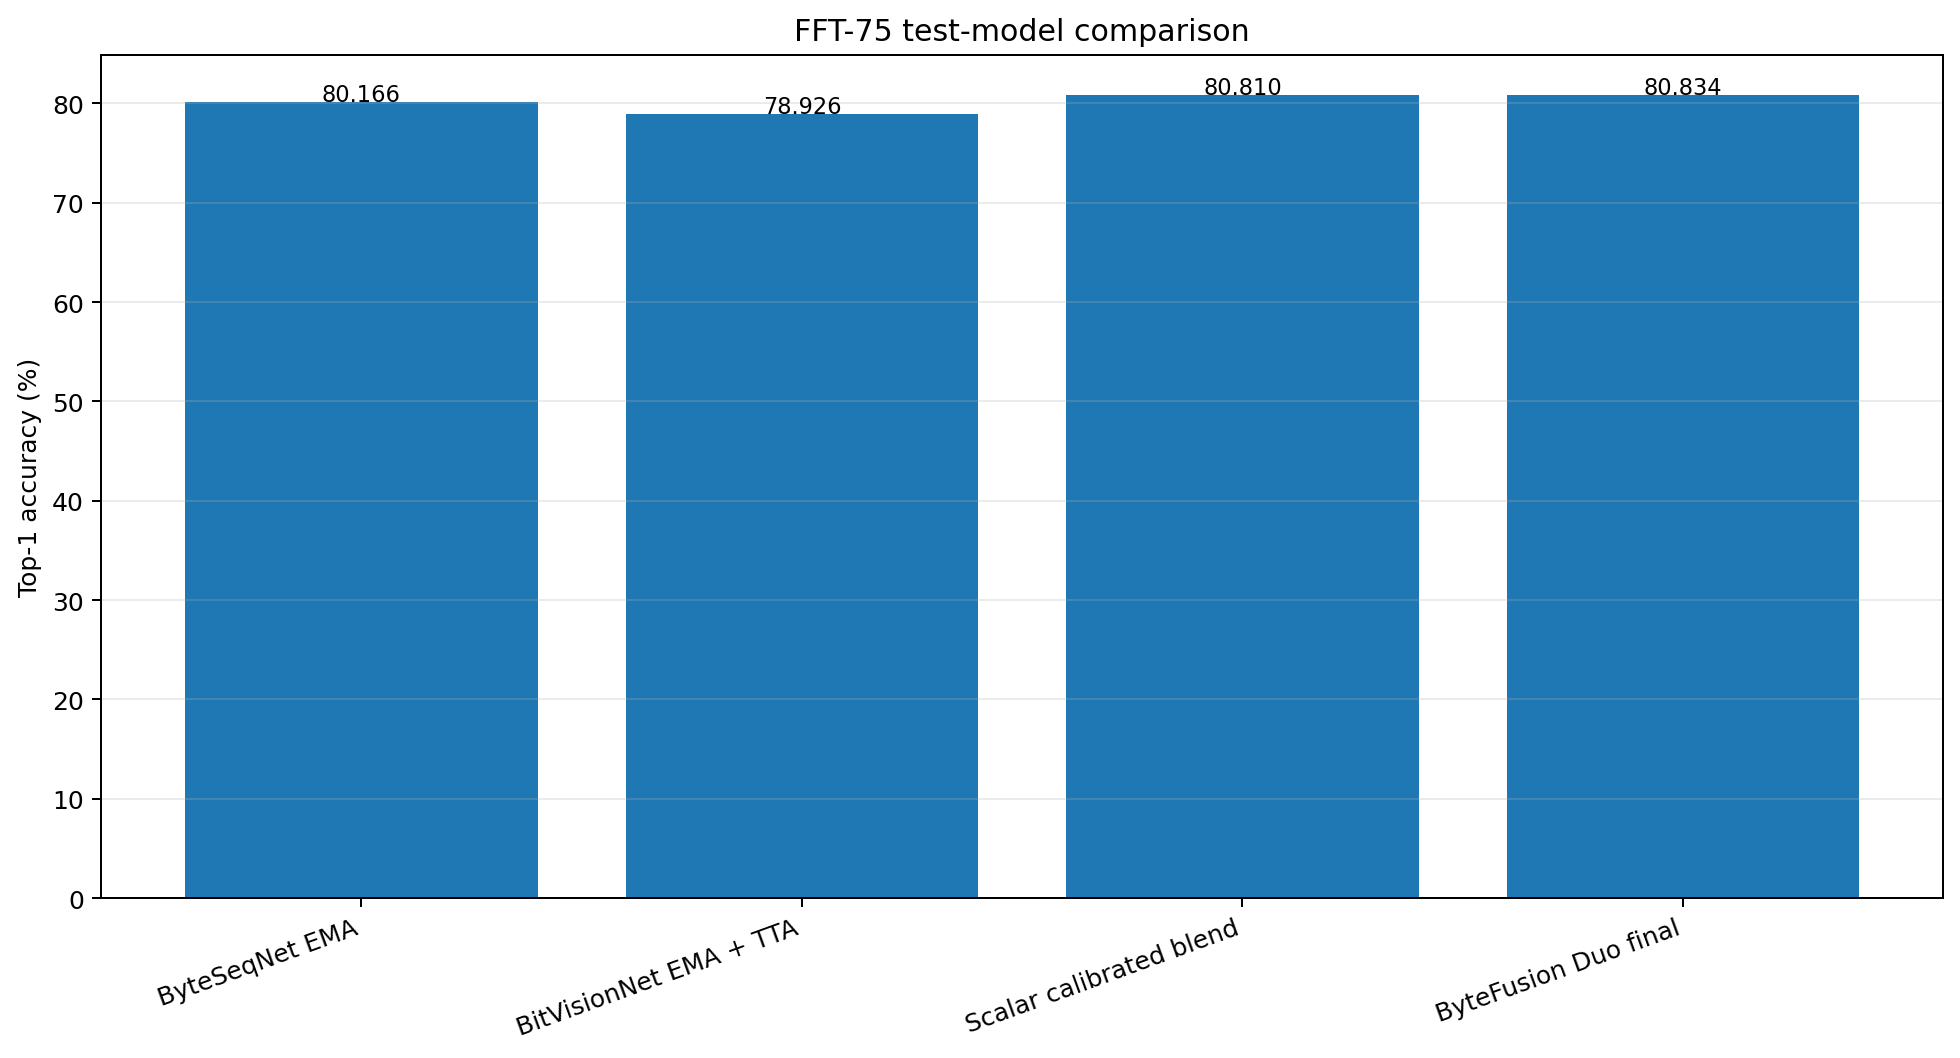

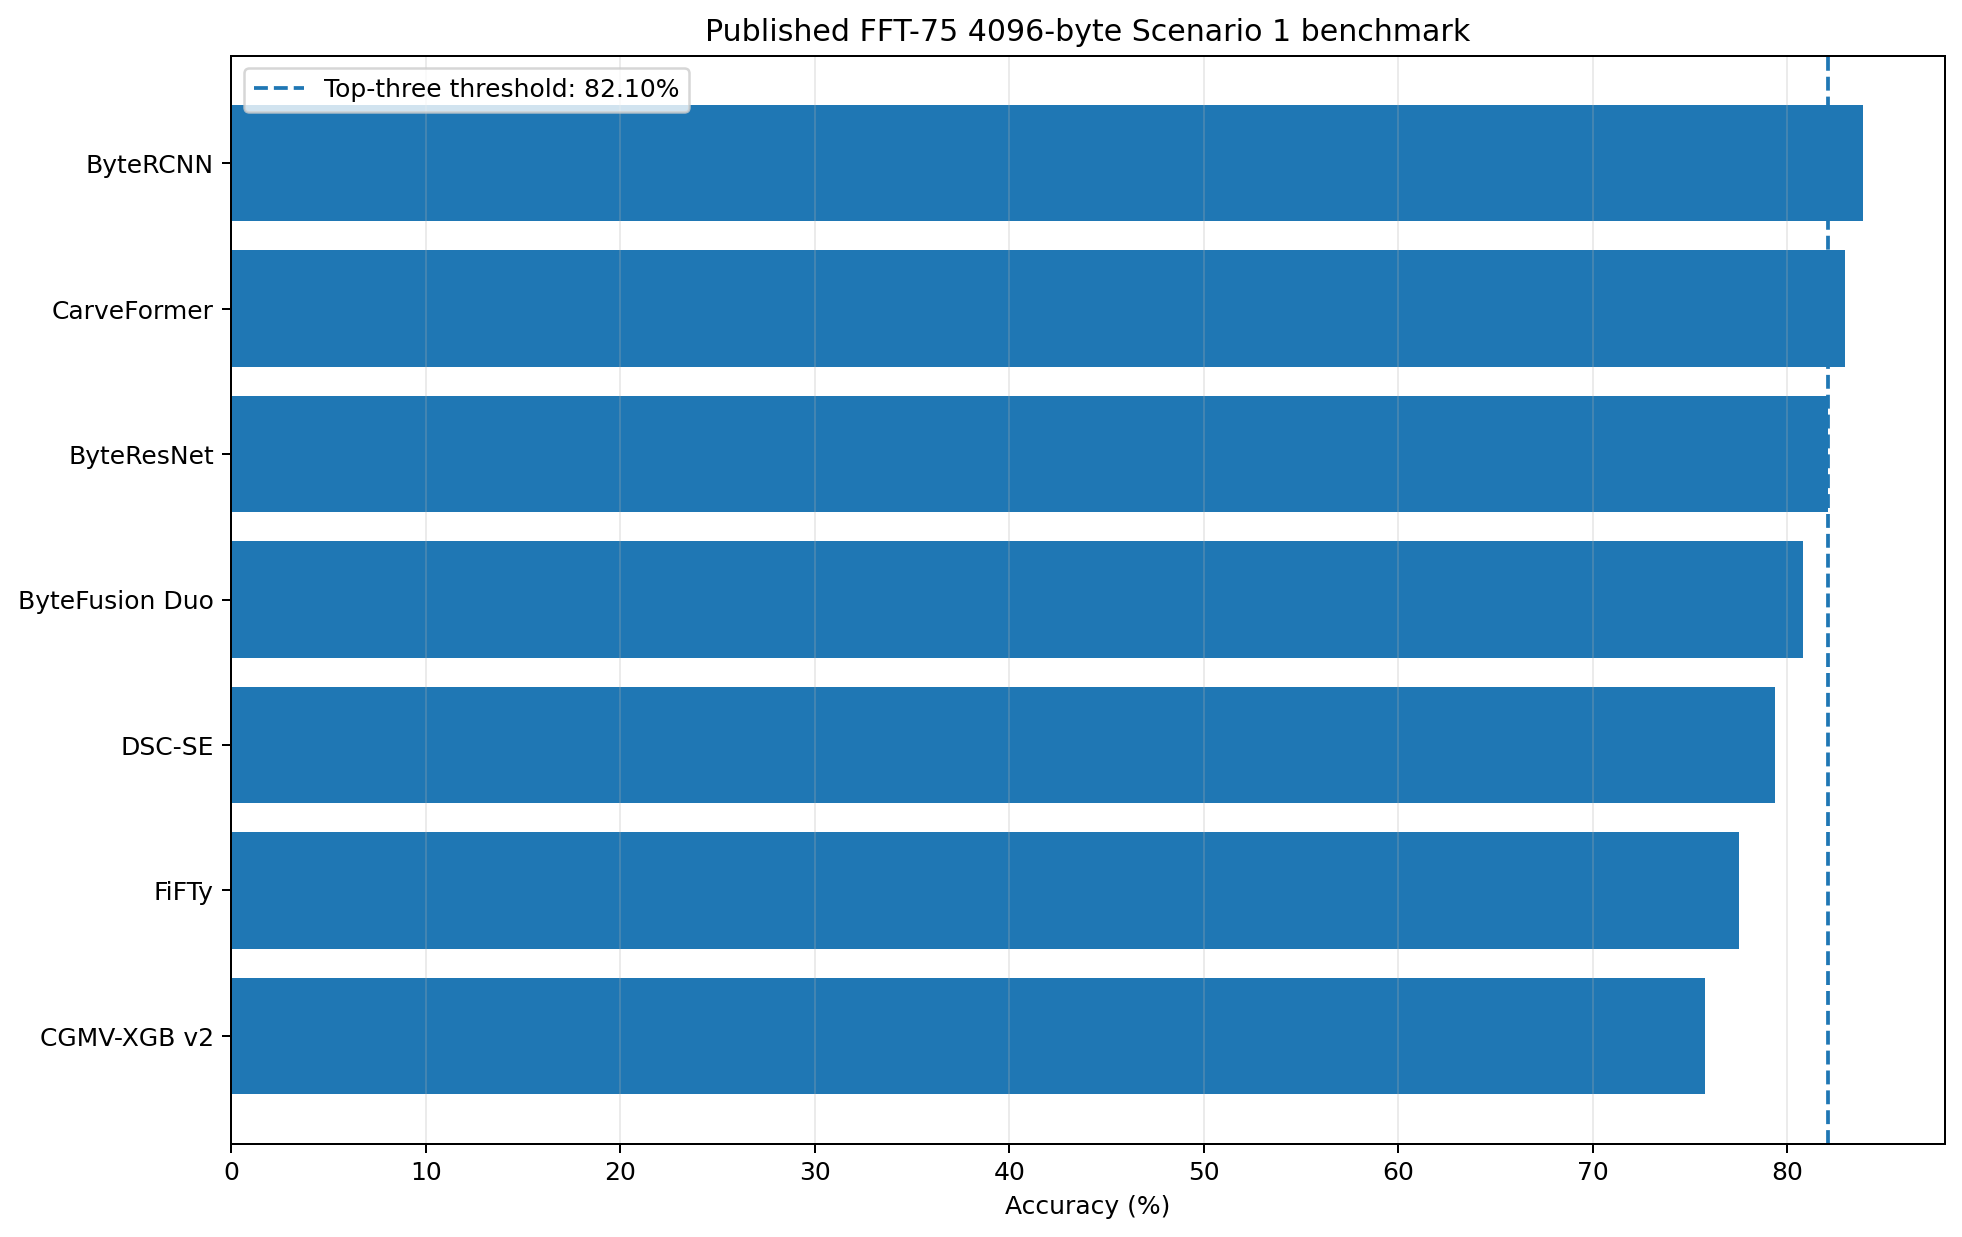

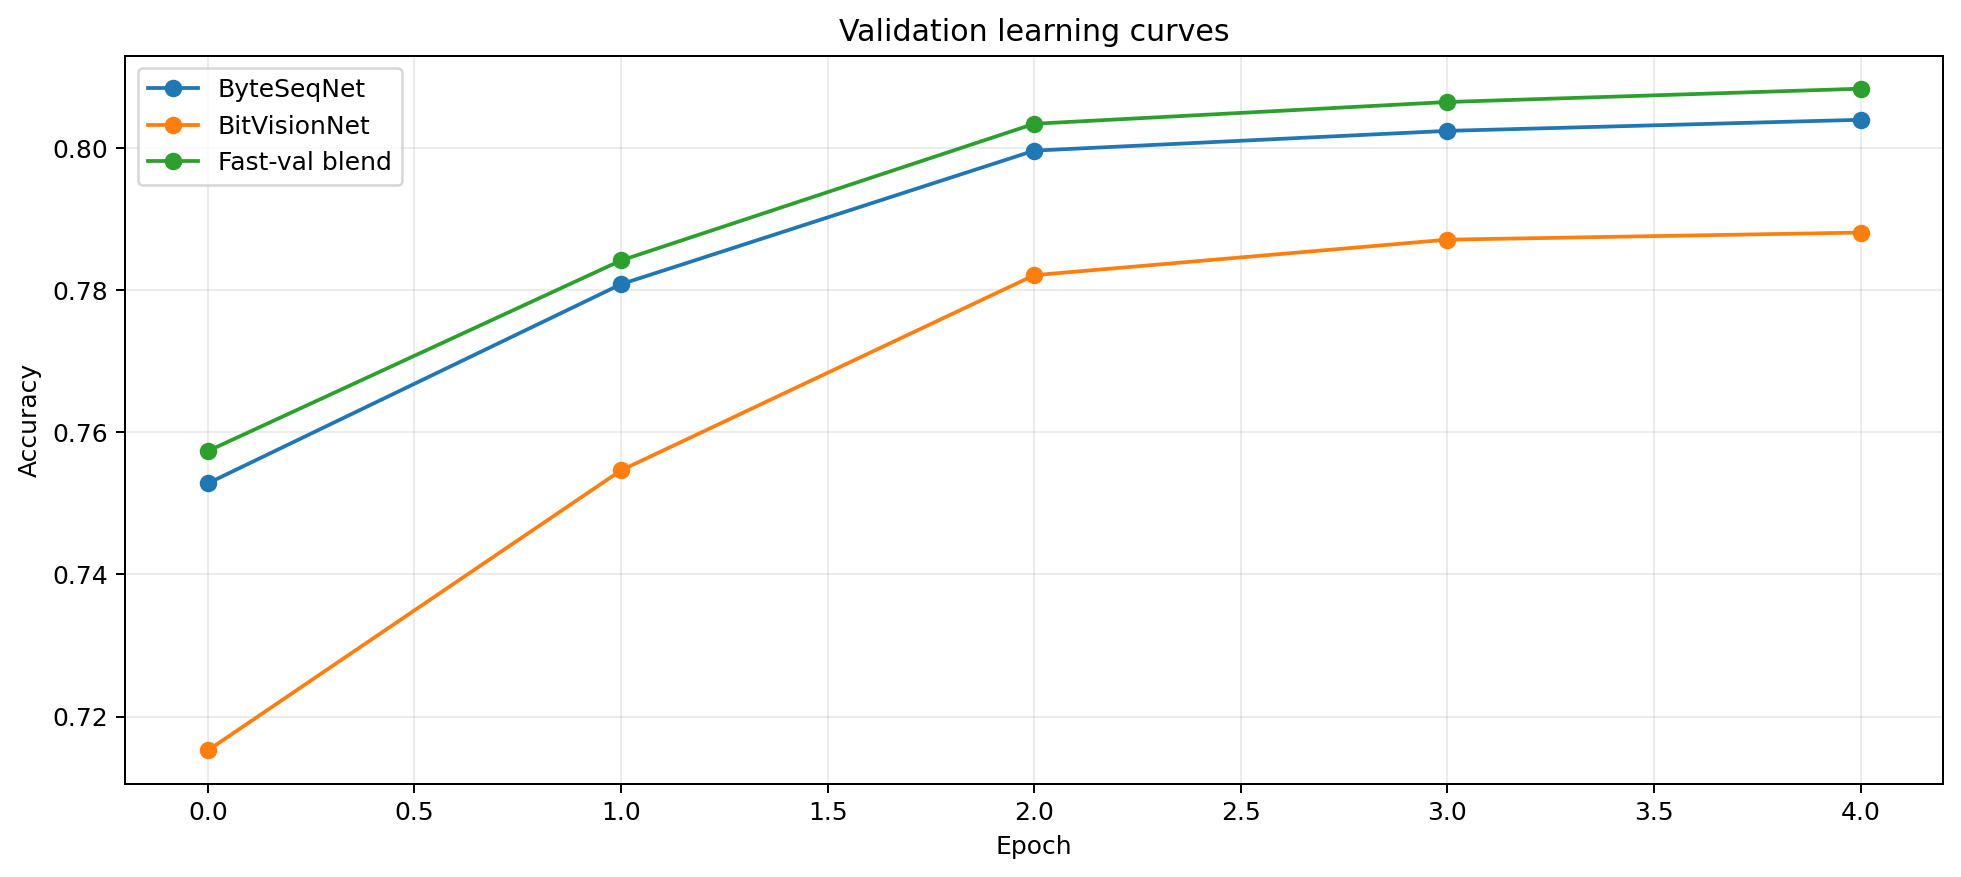

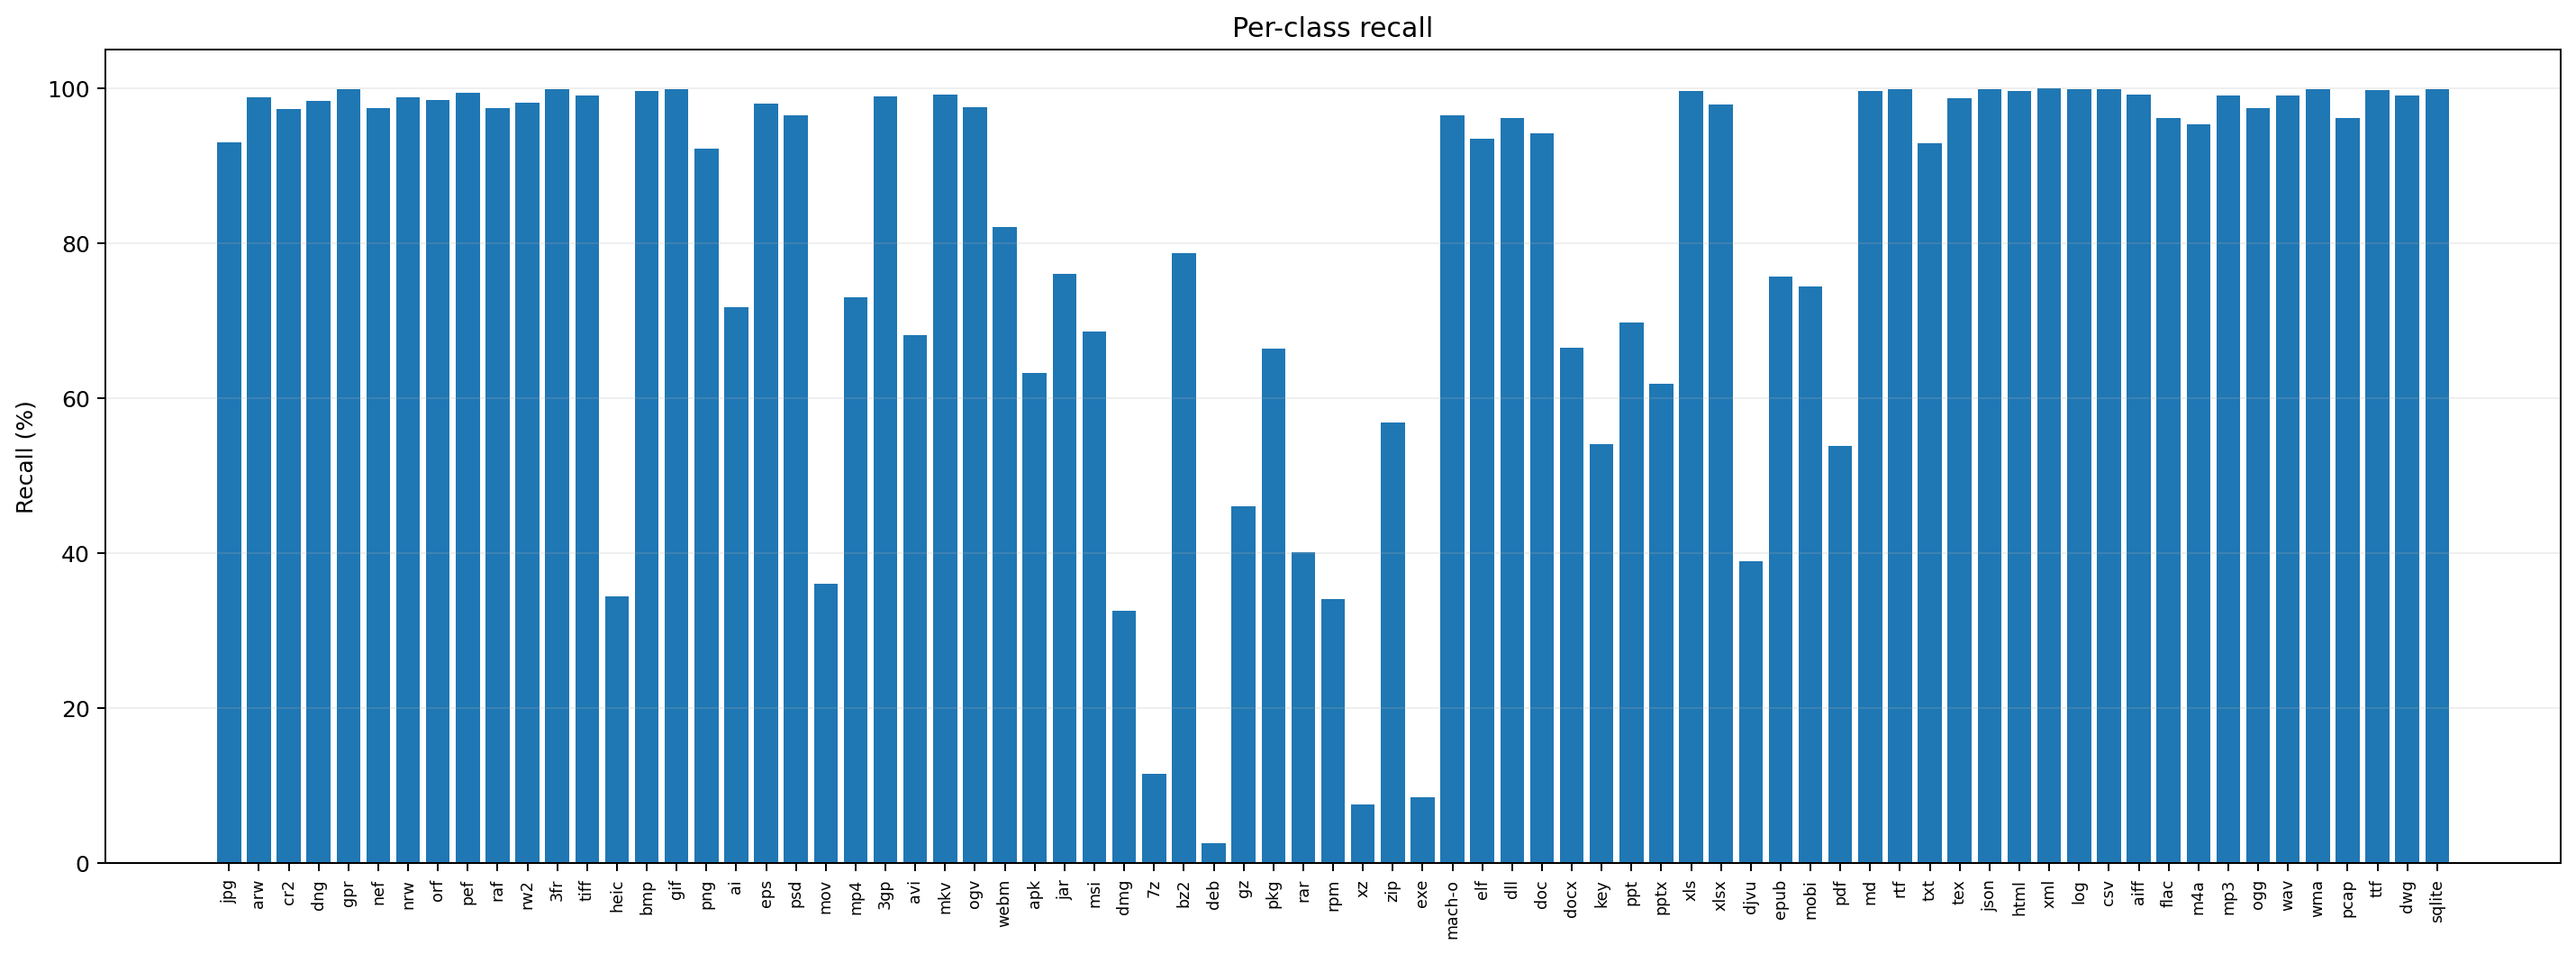

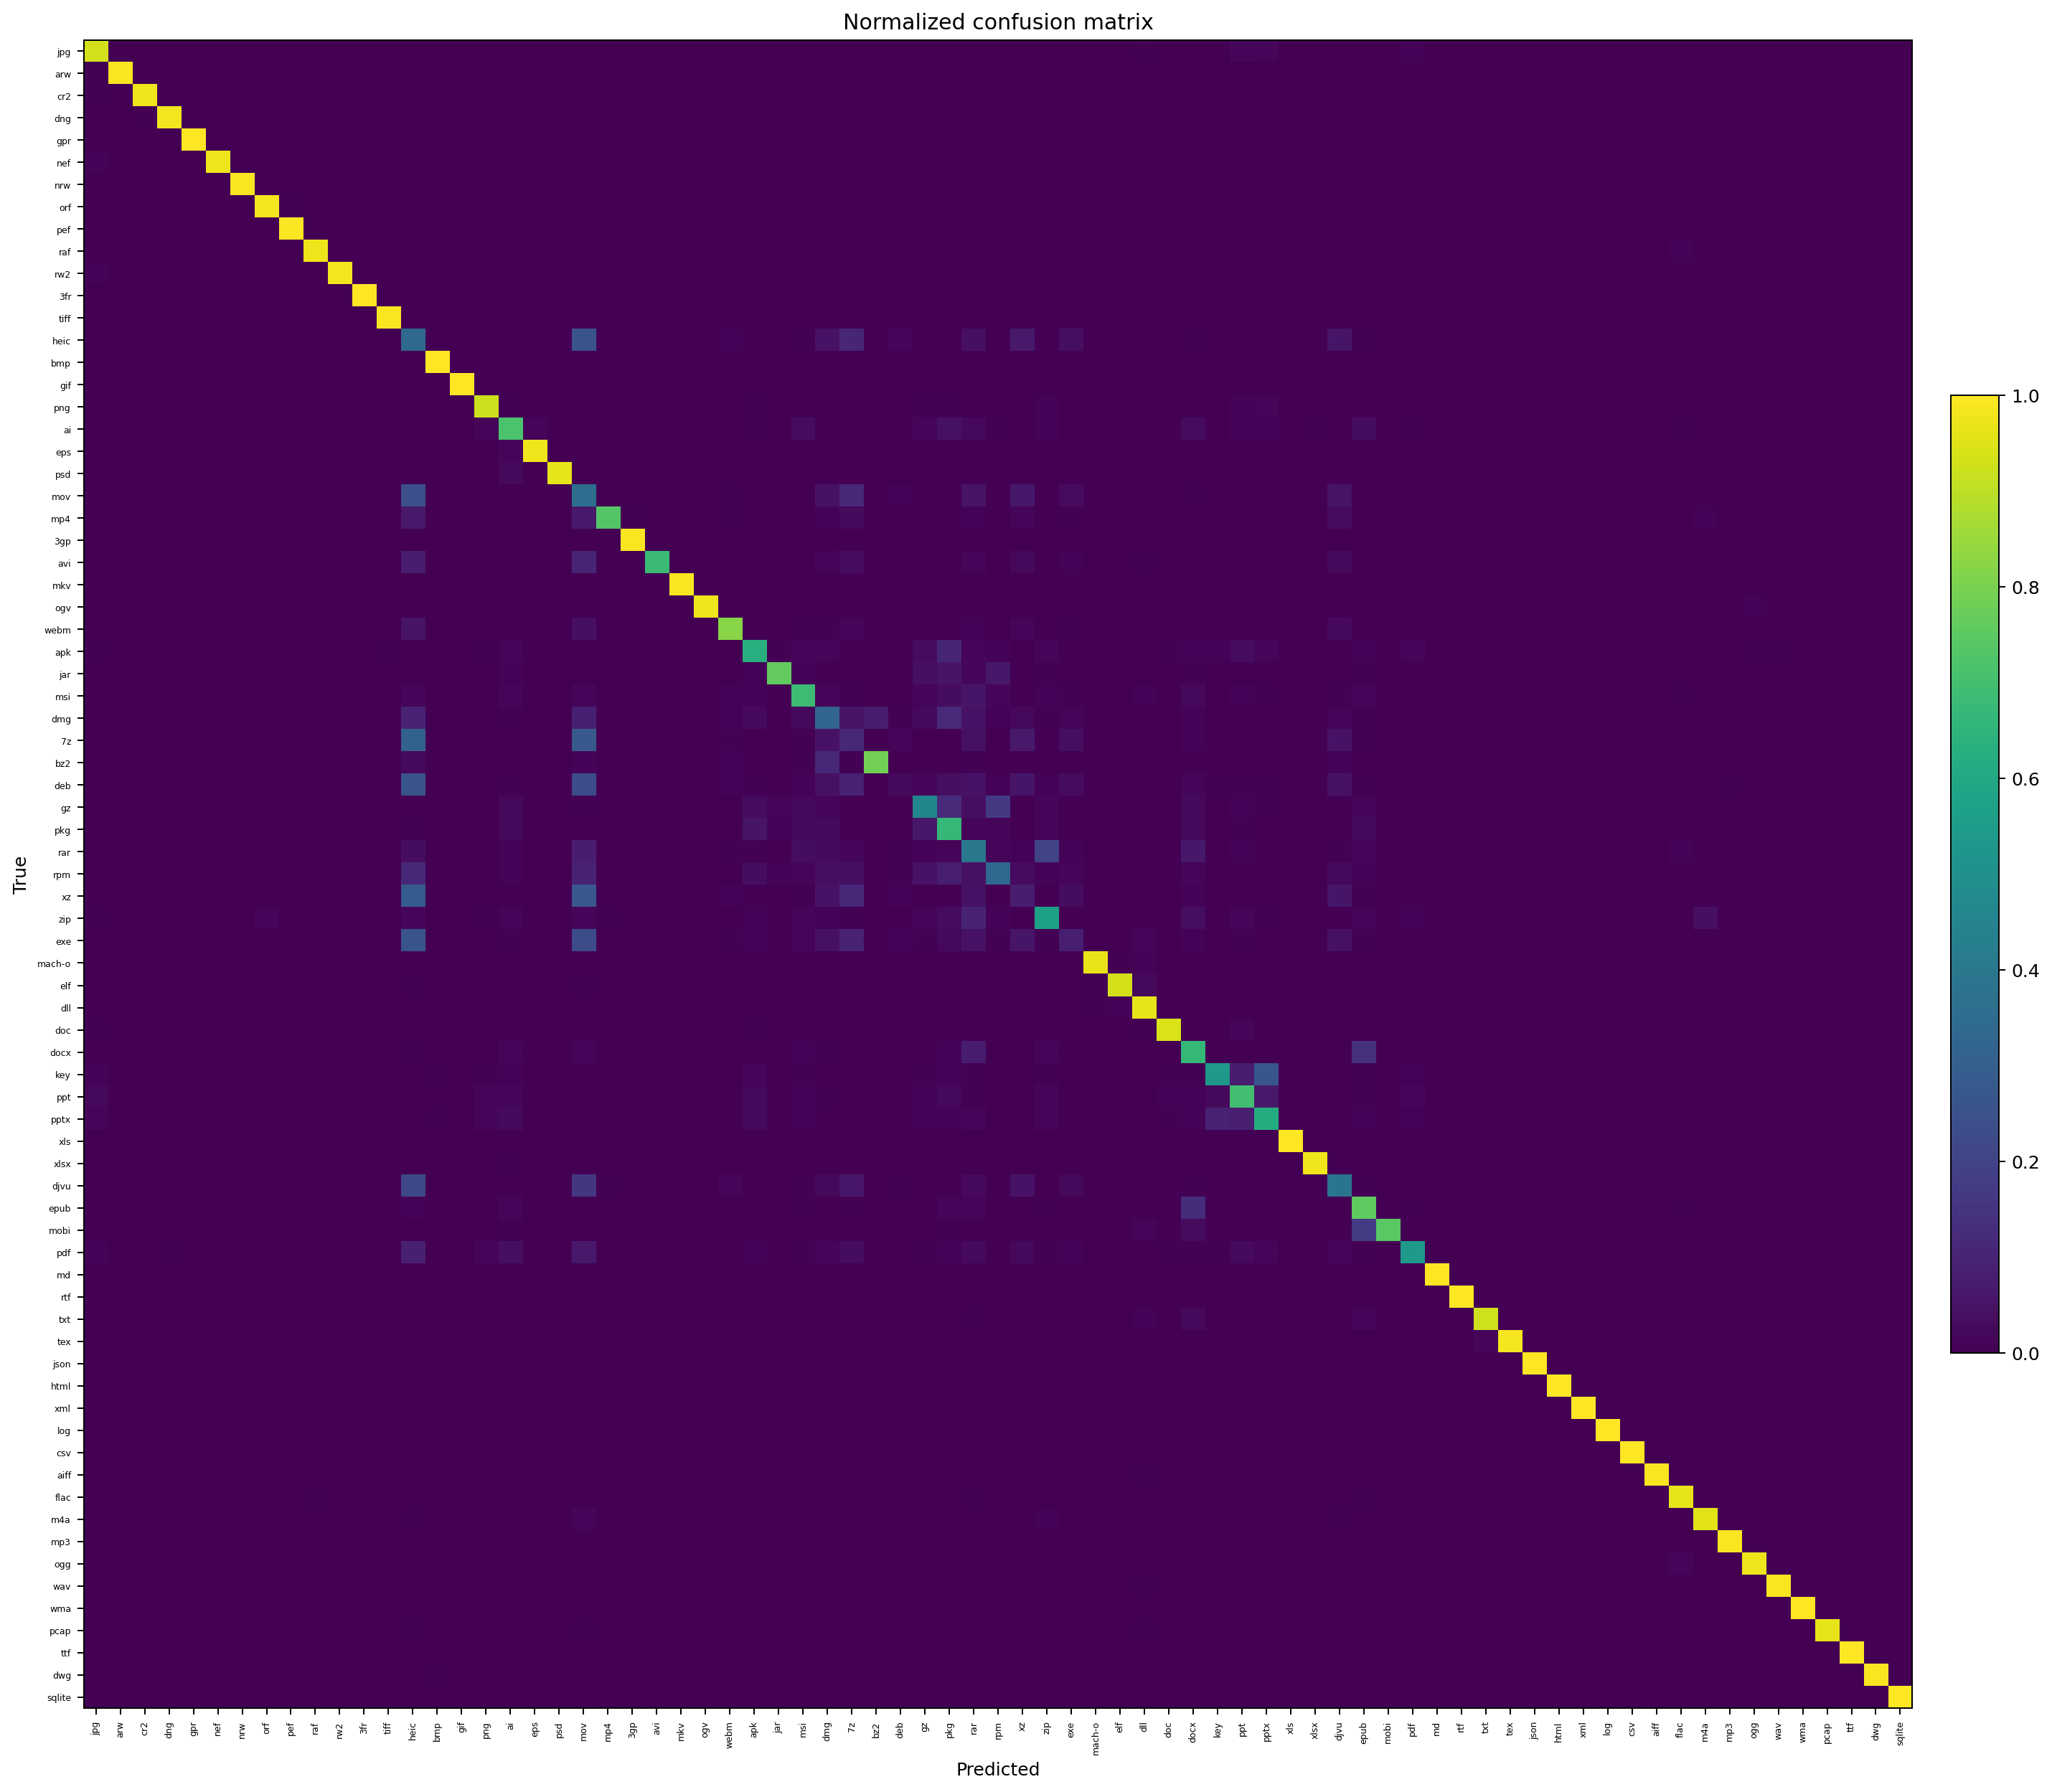

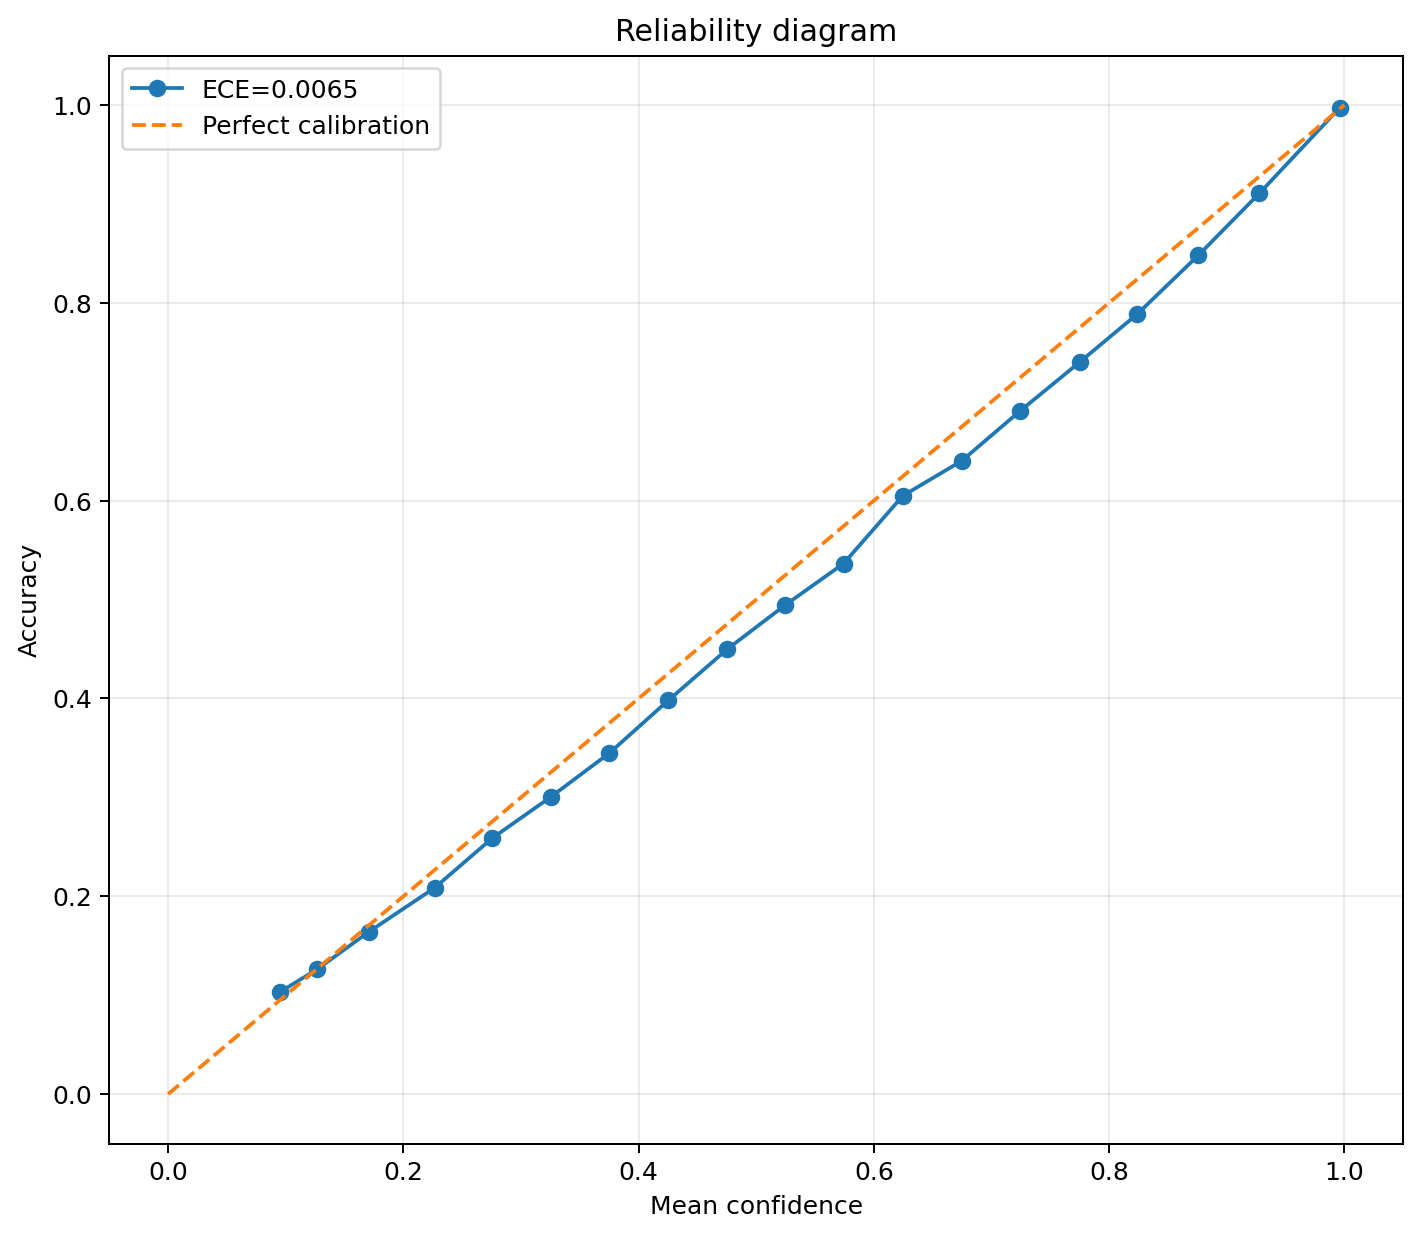

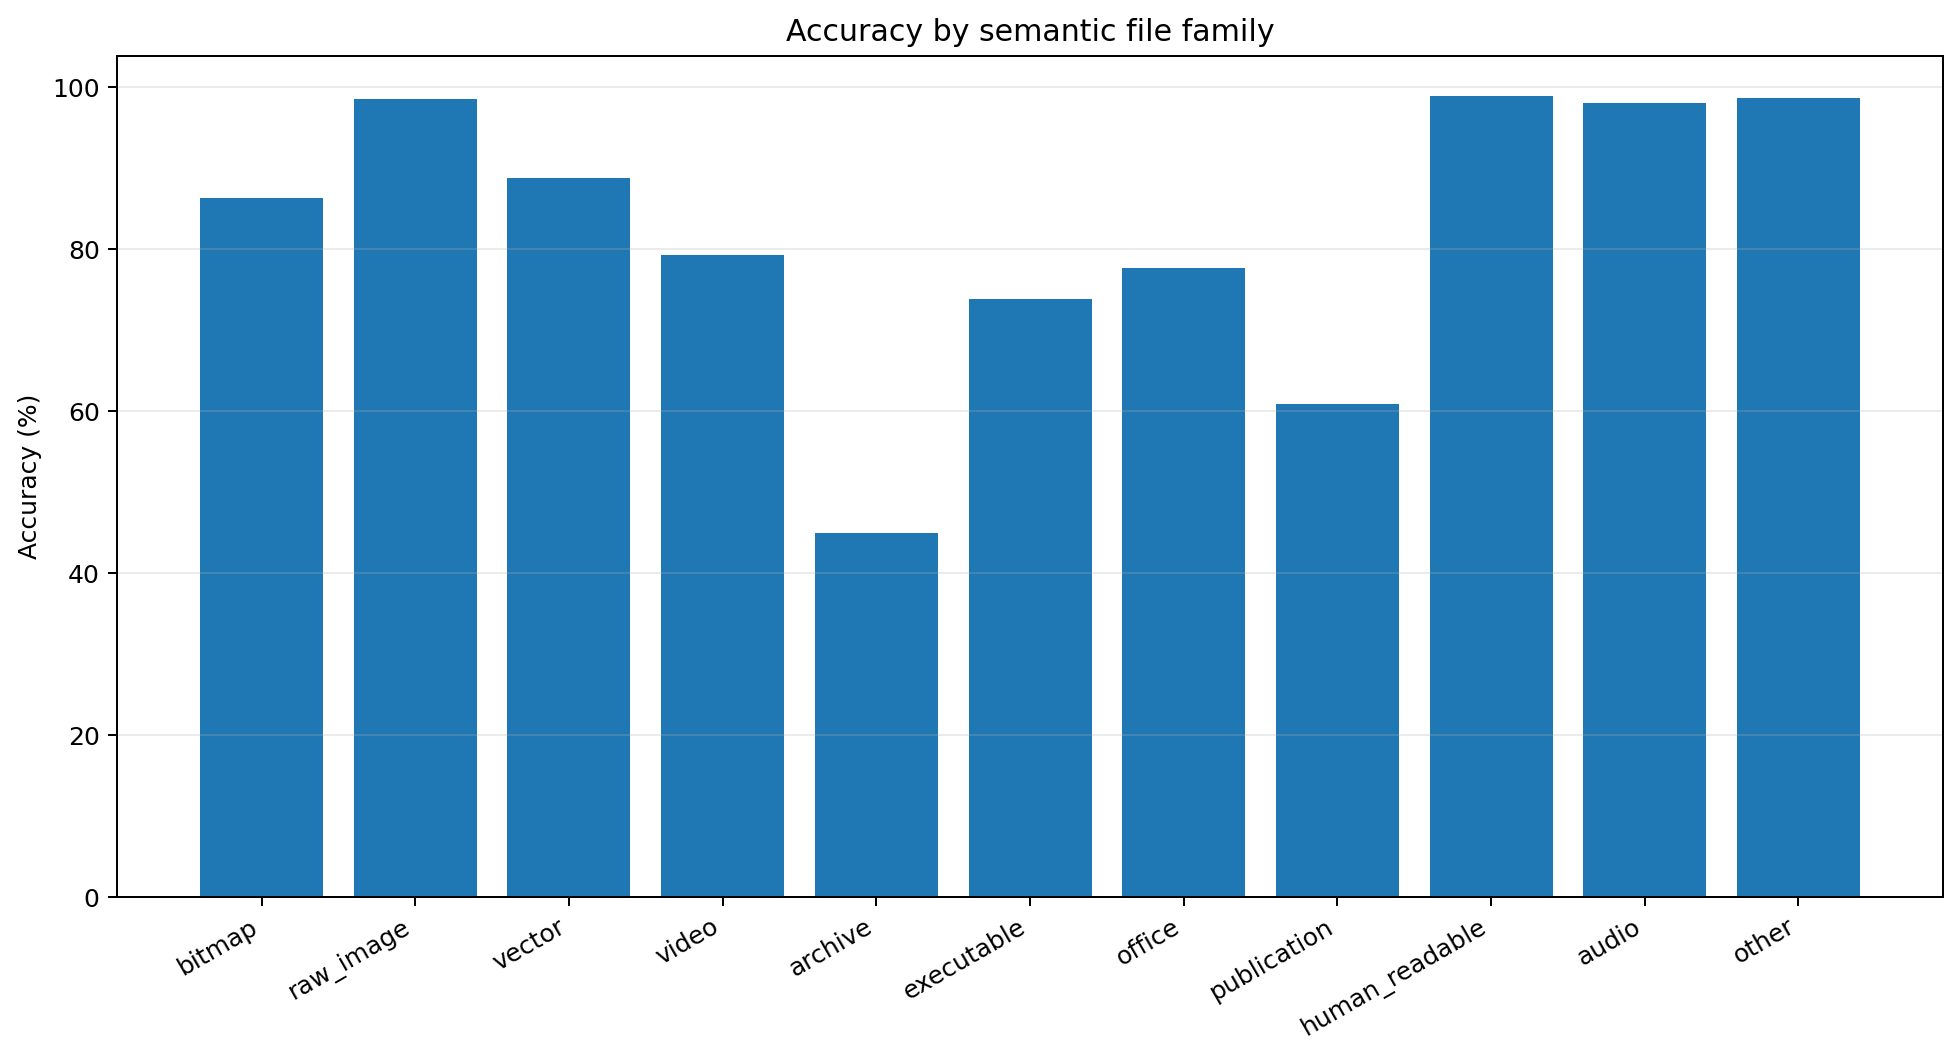

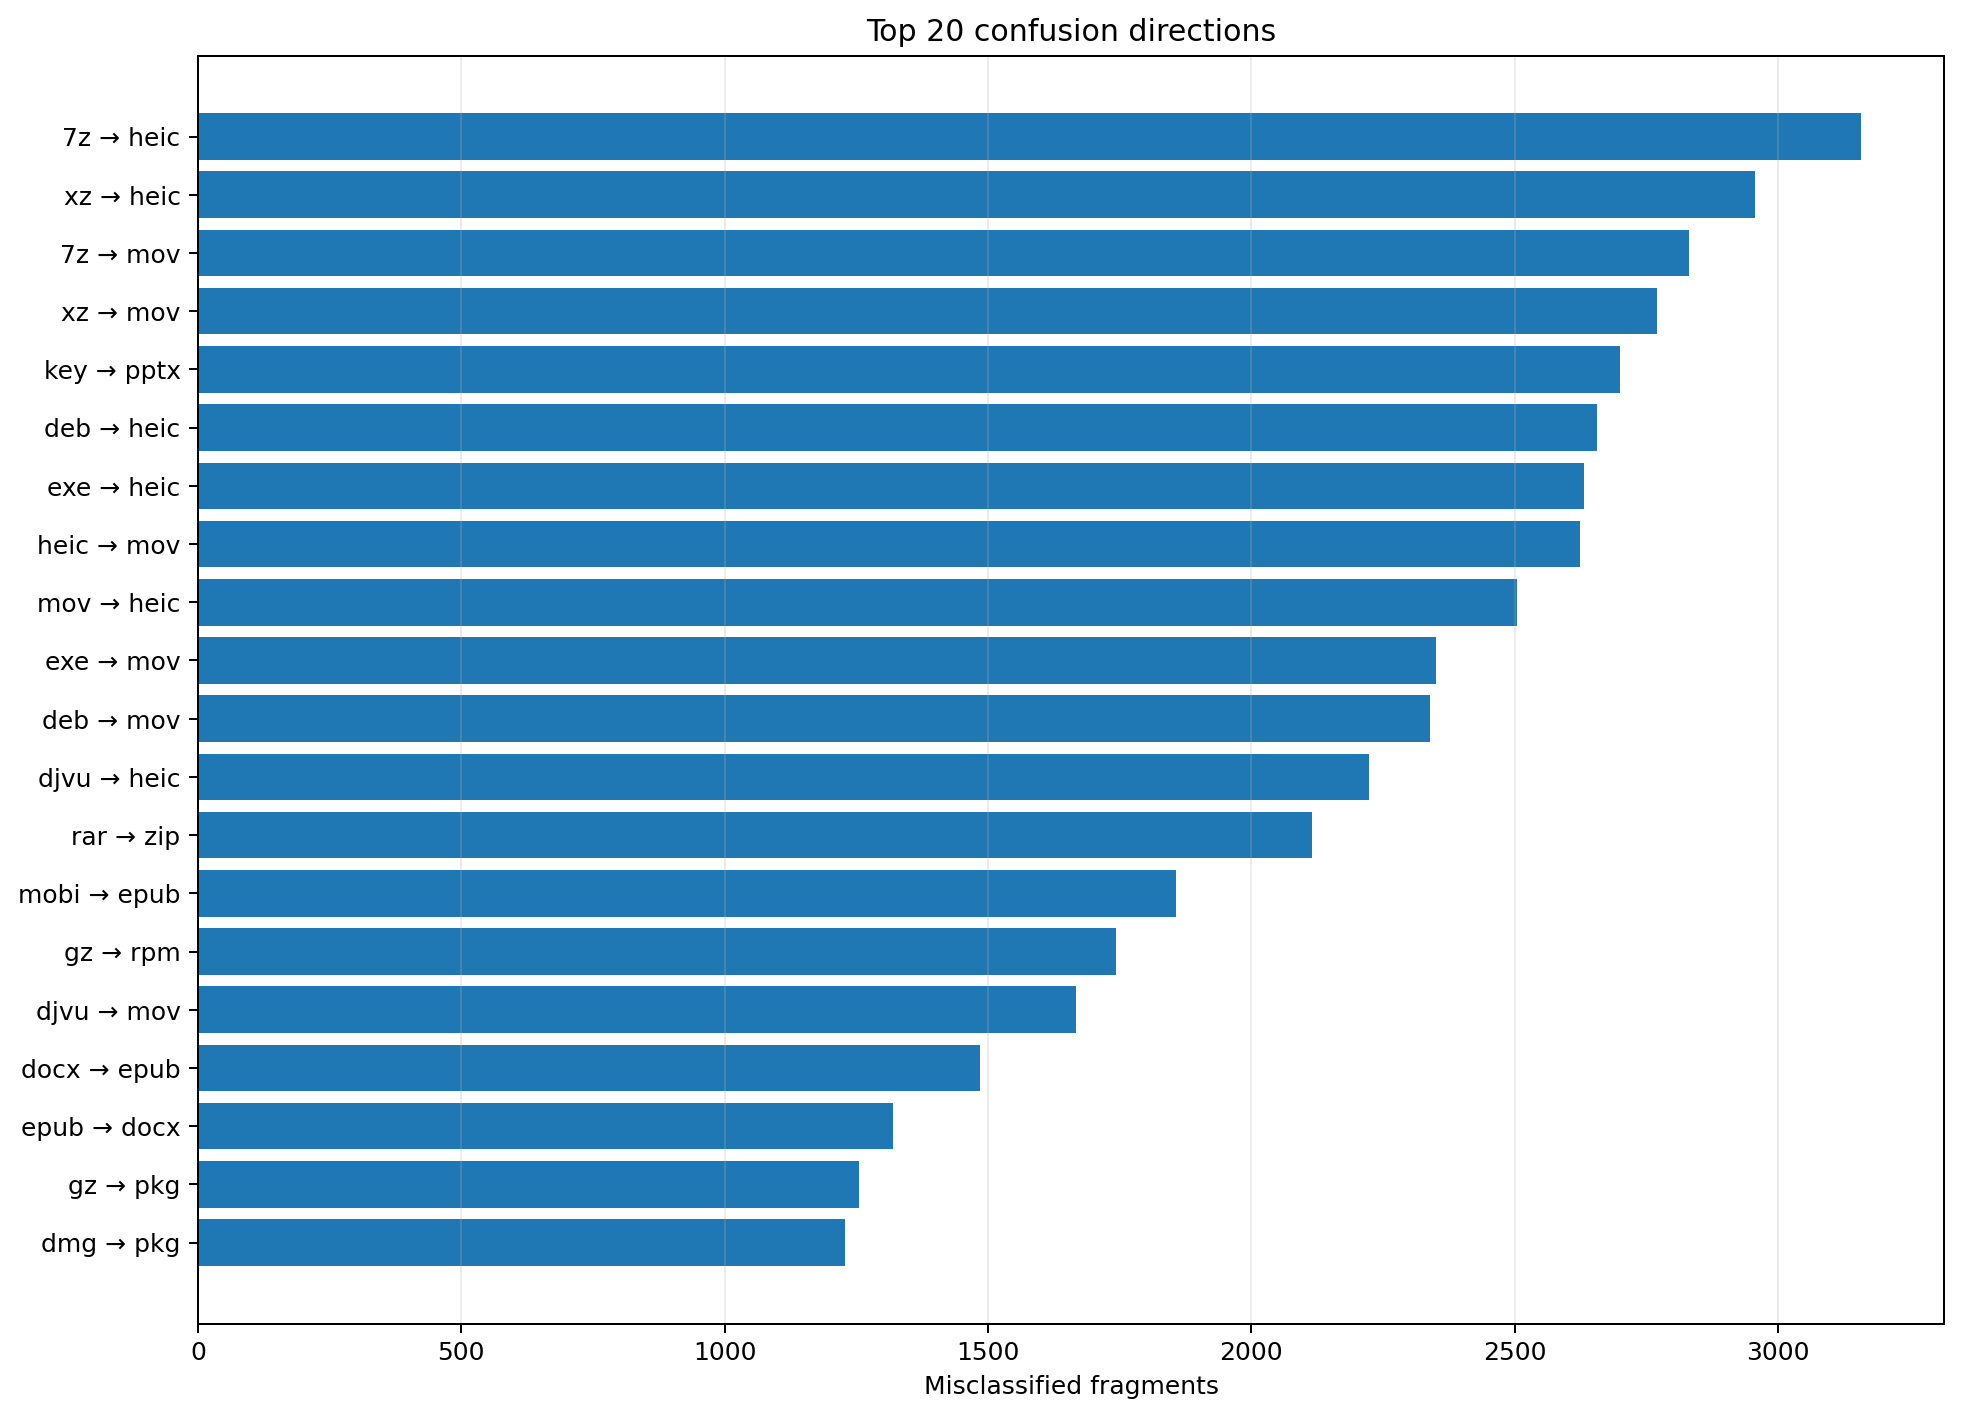

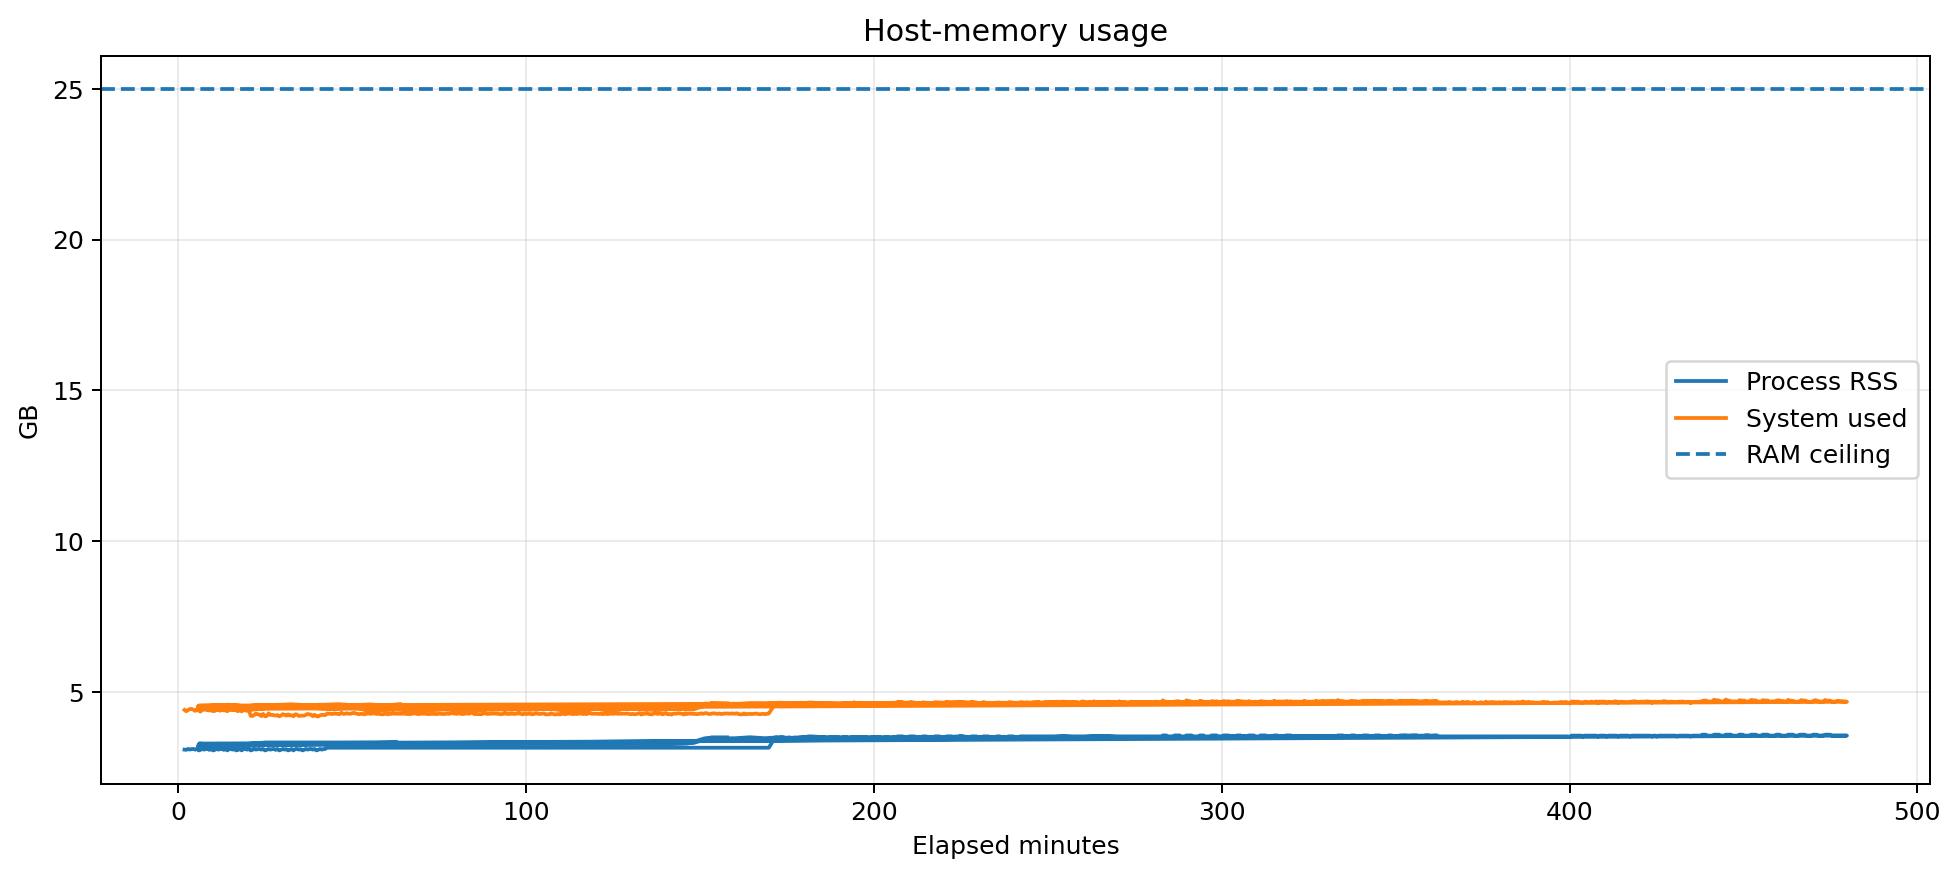

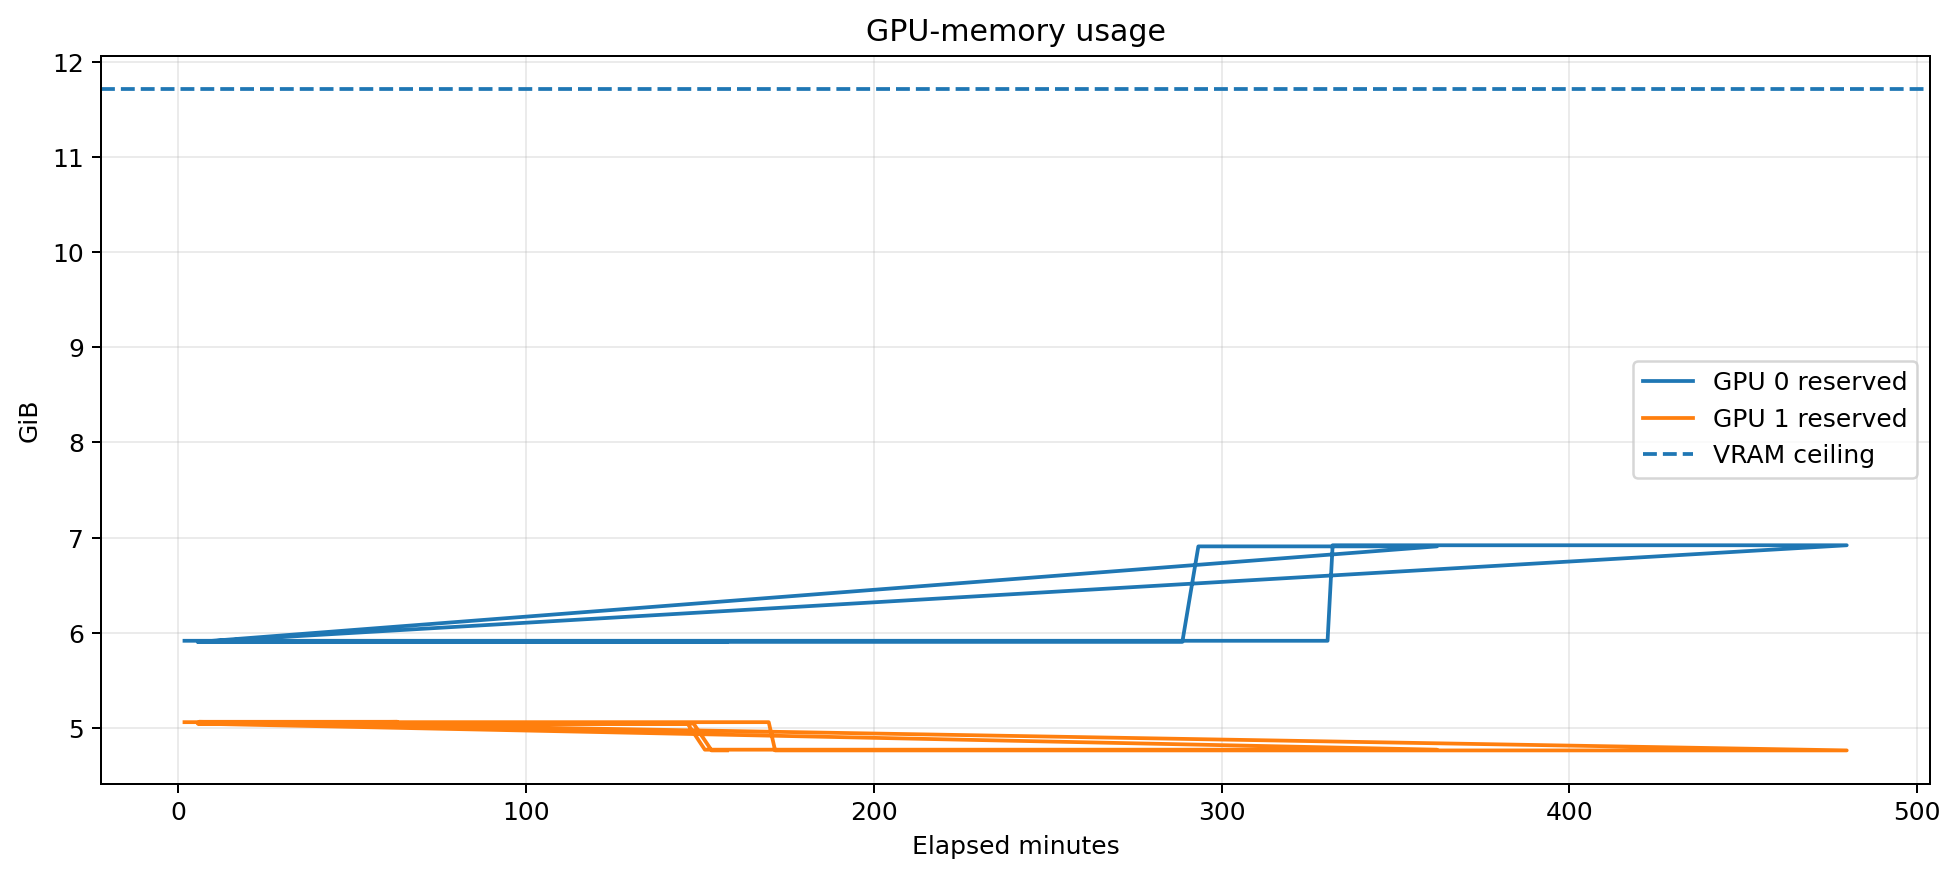

Portable artifact archive: /kaggle/working/fft75_bytefusion_duo_artifacts.zip
Archive size (MB): 27.06


In [20]:

# Run full validation calibration, official test inference, metrics, plots, and packaging.
import pandas as pd

config_path = OUT_DIR / "config.json"
if not config_path.exists():
    raise FileNotFoundError("Training config is missing.")
config = json.loads(config_path.read_text())
# Preserve the original training start timestamp so the evaluator can enforce the 12-hour design.
config["inference_batch_size"] = INFERENCE_BATCH_SIZE
config["vision_tta"] = VISION_TTA
config["total_budget_hours"] = TOTAL_BUDGET_HOURS
config_path.write_text(json.dumps(config, indent=2))

final_summary_path = OUT_DIR / "final_summary.json"
evaluation_log = LOG_DIR / "evaluation.log"
with evaluation_log.open("w") as log_file:
    process = subprocess.Popen(
        [
            sys.executable,
            str(WORK_DIR / "fft75_eval_worker.py"),
            "--config",
            str(config_path),
        ],
        cwd=str(WORK_DIR),
        stdout=log_file,
        stderr=subprocess.STDOUT,
        env={**os.environ, "PYTHONPATH": str(WORK_DIR)},
    )
last_print = 0.0
while process.poll() is None:
    now = time.time()
    if now - last_print >= 60:
        if evaluation_log.exists():
            lines = evaluation_log.read_text(errors="ignore").splitlines()
            print("\n".join(lines[-10:]))
        last_print = now
    if now > float(config["wall_start_unix"]) + TOTAL_BUDGET_HOURS * 3600:
        process.terminate()
        raise TimeoutError(
            "Evaluation exceeded the configured total 12-hour design."
        )
    time.sleep(10)
if evaluation_log.exists():
    print("\n".join(evaluation_log.read_text(errors="ignore").splitlines()[-120:]))
if process.returncode != 0:
    raise RuntimeError(
        f"Evaluation worker failed with return code {process.returncode}."
    )
metrics_df = pd.read_csv(REPORT_DIR / "test_metrics.csv")
display(metrics_df)
display(pd.read_csv(REPORT_DIR / "calibrator_selection.csv"))
display(pd.read_csv(REPORT_DIR / "family_metrics.csv"))
display(pd.read_csv(REPORT_DIR / "top_confusions.csv").head(20))

final_summary = json.loads(final_summary_path.read_text())
print(json.dumps(final_summary, indent=2))

from IPython.display import Image, display as ipy_display
for name in [
    "test_model_comparison.png",
    "published_benchmark_comparison.png",
    "validation_learning_curves.png",
    "per_class_recall.png",
    "confusion_matrix_normalized.png",
    "reliability_diagram.png",
    "family_accuracy.png",
    "top_confusions.png",
    "host_memory_usage.png",
    "gpu_memory_usage.png",
]:
    path = PLOT_DIR / name
    if path.exists():
        ipy_display(Image(filename=str(path)))

artifact_archive = WORK_DIR / "fft75_bytefusion_duo_artifacts.zip"
print("Portable artifact archive:", artifact_archive)
print("Archive size (MB):", round(artifact_archive.stat().st_size / 2**20, 2))



## Interpretation and publication checklist

The final report should emphasize:

- Test accuracy, macro F1, balanced accuracy, MCC, log loss, top-3/top-5 accuracy, and Wilson confidence interval.
- Whether the regularized classwise blender beat the scalar blend on the held-out validation-selection half.
- McNemar's exact paired test between the scalar blend and the final model.
- Per-class and per-family recall, especially raw-image, archive, office, publication, and human-readable families.
- Top directional confusions using real file-type names rather than numeric labels.
- Peak RAM and per-GPU reserved VRAM from the resource logs.
- Total training time and whether training ended through early stopping or the wall-clock budget.
- The final official test result should not be used for additional tuning in a publishable evaluation cycle.

Large validation/test logits and probabilities remain under `predictions/` for auditability. The portable ZIP intentionally excludes those large arrays while retaining the best model weights, calibrator, reports, plots, metadata, and significance results.
